# Personal Information
Name: **Jia Long Bao**

StudentID: **12593400**

Email: [**jialong.bao@student.uva.nl**](jialong.bao@student.uva.nl)

Submitted on: **31.10.2025**

# Data Context

The data utilized in this research is obtained from various sources, capturing spatial, temporal and external factors that influence train delays in the Netherlands.

The main dataset is from Rijden De Treinen, a platform that processes real-time open data from NDOV (Nationale Data Openbaar Vervoer), the data contains historical and along with their actual realized train services from the beginning of 2019 till beginning of 2025. Each row in the dataset represents a stop at a station. Each service at least departs and arrives at a station, thus resulting in 2 rows. 

The spatial data, including station locations and connections is also extracted from Rijden De Treinen. This ensures an accurate representation of the railway network, which forms the foundation of modeling the graph structure. 

The temporal data consists of the historical train schedules, recorded delays and disruptions all sourced from Rijden De Treinen.

This is further complemented with a (dutch national) holiday dataset is obtained from the official python holidays package and a weather dataset from OpenMeteo Historical Weather API (publicly available).

Github: https://github.com/jbaonl/MSc-Thesis

# Data Description

In [3]:
# Imports
import os
import numpy as np
import pandas as pd
import matplotlib as plt
import seaborn as sns
import networkx as nx
import re
import duckdb
from pathlib import Path

### Data Loading

#### Set root folder path 

In [4]:
import os
from pathlib import Path

target_root = Path(r"C:\Users\jialo\Desktop\MSc-DS-Thesis\MSc-Thesis-Repo\MSc-Thesis\Bao")

# Check if it exists before moving
if target_root.exists():
    os.chdir(target_root)
    print(f"✅ Success! Moved to: {Path.cwd()}")
else:
    print(f"❌ Error: The folder '{target_root}' does not exist.")

✅ Success! Moved to: C:\Users\jialo\Desktop\MSc-DS-Thesis\MSc-Thesis-Repo\MSc-Thesis\Bao


In [ ]:
project_root = target_root

root_folder =  project_root / "downloads/data/raw/"
filtered_output_root_folder = project_root / "downloads/data/filtered/"

services_path = root_folder / "NS-services/services_merged_all_ns_only.parquet"
disruptions_path = root_folder / "NS-disruptions/disruptions_merged_all.parquet"
stations_path = root_folder / "NS-stations/stations-2023-09-nl.csv" #duckdb seem to handle 'NA' station code properly, so we can just load the original file
station_distances_path = root_folder / "NS-tariff-distances/tariff-distances-2022-01.csv" #probably not used in eda, might only be useful for graph edges feature
# stations_connections_path = root_folder / "railway_map/connection_edges.parquet"

weather_path = root_folder / "weather/weather_merged_all.parquet"
holiday_path = root_folder / "holidays/dutch_holidays_2019_2025.parquet"

EDA_folder = project_root / "media/EDA"

# 1. Setup paths to iterate over

paths = {
    "Services": services_path,
    "Disruptions": disruptions_path,
    "Stations": stations_path,
    "Station Distances": station_distances_path,
    "Weather": weather_path,
    "Holidays": holiday_path
}


#### Duckdb prep

In [ ]:
import duckdb
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import networkx as nx
from pathlib import Path

# 2. Initialize Disk-Based Database
# This creates a file 'ns_data.duckdb' in your current folder.
# Intermediate calculations (joins/group bys) will spill here instead of crashing RAM.
con = duckdb.connect(database='ns_data.duckdb') 

# 3. Register Views (Zero-Copy)
# We use VIEWs so we don't duplicate the Parquet data into the .duckdb file.
# DuckDB reads directly from the parquet files on demand.
con.execute(f"CREATE OR REPLACE VIEW raw_services AS SELECT * FROM read_parquet('{services_path}')")
con.execute(f"CREATE OR REPLACE VIEW raw_disruptions AS SELECT * FROM read_parquet('{disruptions_path}')")
con.execute(f"CREATE OR REPLACE VIEW raw_weather AS SELECT * FROM read_parquet('{weather_path}')")
con.execute(f"CREATE OR REPLACE TABLE stations AS SELECT * FROM read_csv_auto('{stations_path}')")
con.execute(f"CREATE OR REPLACE VIEW raw_holidays AS SELECT * FROM read_parquet('{holiday_path}')")
con.execute(f"CREATE OR REPLACE VIEW raw_station_distances AS SELECT * FROM read_csv_auto('{station_distances_path}')")
# con.execute(f"CREATE OR REPLACE VIEW raw_stations_connections AS SELECT * FROM read_parquet('{stations_connections_path}')")

# 4. Create CLEAN Views (Logic remains the same, but executed safely)
con.execute("""
    CREATE OR REPLACE VIEW services AS 
    SELECT 
        "Service:RDT-ID" AS service_id,
        "Service:Date" AS service_date,
        "Service:Type" AS train_type,
        "Stop:Departure Delay" AS departure_delay_min,
        "Stop:Station code" AS station_code,
        "Stop:Station name" AS station_name,
        
        -- Apply Timezone conversion HERE in the SELECT statement
        ("Stop:Arrival time" AT TIME ZONE 'Europe/Amsterdam')::TIMESTAMP AS arrival_time,
        
        "Stop:Arrival cancelled" AS is_cancelled,
        
        -- Apply Timezone conversion HERE too
        ("Stop:Departure time" AT TIME ZONE 'Europe/Amsterdam')::TIMESTAMP AS departure_time
    FROM raw_services
""")

print("✅ Table 'services' created with clean names and local timestamps.")

con.execute("""
    CREATE OR REPLACE VIEW disruptions AS 
    SELECT 
        *,
        CASE 
            WHEN rdt_station_codes LIKE '[%]' 
            THEN string_split(trim(rdt_station_codes, '[]'), ', ') 
            ELSE string_split(rdt_station_codes, ',') 
        END AS station_array
    FROM raw_disruptions
""")

print("Disk-based database initialized. Queries will now spill to 'ns_data.duckdb' if needed.")


KeyboardInterrupt



In [7]:
# This shows Column Name, Column Type, Nullable, etc.
duckdb.sql(f"DESCRIBE SELECT * FROM '{services_path}'").show()
# This gives you stats per column, including missing values (null_percentage)
duckdb.sql(f"SUMMARIZE SELECT * FROM '{services_path}'").show()


┌──────────────────────────────┬──────────────────────────┬─────────┬─────────┬─────────┬─────────┐
│         column_name          │       column_type        │  null   │   key   │ default │  extra  │
│           varchar            │         varchar          │ varchar │ varchar │ varchar │ varchar │
├──────────────────────────────┼──────────────────────────┼─────────┼─────────┼─────────┼─────────┤
│ Service:RDT-ID               │ BIGINT                   │ YES     │ NULL    │ NULL    │ NULL    │
│ Service:Date                 │ DATE                     │ YES     │ NULL    │ NULL    │ NULL    │
│ Service:Type                 │ VARCHAR                  │ YES     │ NULL    │ NULL    │ NULL    │
│ Service:Company              │ VARCHAR                  │ YES     │ NULL    │ NULL    │ NULL    │
│ Service:Train number         │ BIGINT                   │ YES     │ NULL    │ NULL    │ NULL    │
│ Service:Completely cancelled │ BOOLEAN                  │ YES     │ NULL    │ NULL    │ NULL    │


In [9]:
display(con.execute("DESCRIBE services").df())
display(con.execute("SUMMARIZE services").df())

,column_name,column_type,null,key,default,extra
0,service_id,BIGINT,YES,None,None,None
1,service_date,DATE,YES,None,None,None
2,train_type,VARCHAR,YES,None,None,None
3,arrival_delay_min,BIGINT,YES,None,None,None
4,departure_delay_min,BIGINT,YES,None,None,None
5,station_code,VARCHAR,YES,None,None,None
6,station_name,VARCHAR,YES,None,None,None
7,arrival_time,TIMESTAMP,YES,None,None,None
8,arrival_delay_min_1,BIGINT,YES,None,None,None
9,is_cancelled,BOOLEAN,YES,None,None,None


,column_name,column_type,min,max,approx_unique,avg,std,q25,q50,q75,count,null_percentage
0,service_id,BIGINT,738804,15101626,8522415,7820391.652574129,4149532.2577732964,4217459,7747719,11401309,83816585,0.00
1,service_date,DATE,2019-01-01,2024-12-31,2523,2021-12-16 21:16:59.316332,None,2020-06-17,2021-12-05,2023-06-16,83816585,0.00
2,train_type,VARCHAR,Eurostar,Thalys,10,None,None,None,None,None,83816585,0.00
3,arrival_delay_min,BIGINT,-92,1469,435,0.7099777193286492,2.850872643989108,0,0,0,83816585,9.70
4,departure_delay_min,BIGINT,-62,1470,363,0.7229577707526456,2.7041430396800177,0,0,1,83816585,9.69
5,station_code,VARCHAR,AC,ZZS,417,None,None,None,None,None,83816585,0.00
6,station_name,VARCHAR,'s-Hertogenbosch,Zwolle,473,None,None,None,None,None,83816585,0.00
7,arrival_time,TIMESTAMP,2019-01-01 02:12:00,2025-01-01 02:51:00,3297673,2021-12-18 13:27:21.398902,None,2020-06-16 20:41:41.289422,2021-12-07 19:31:21.87881,2023-06-19 01:30:30.940173,83816585,9.70
8,arrival_delay_min_1,BIGINT,-92,1469,435,0.7099777193286492,2.850872643989108,0,0,0,83816585,9.70
9,is_cancelled,BOOLEAN,false,true,2,None,None,None,None,None,83816585,9.70


In [8]:
# # This gives you stats per column, including missing values (null_percentage)
# md_output = duckdb.sql(f"DESCRIBE SELECT * FROM '{holiday_path}'").df().to_markdown()
# duckdb.sql(f"SUMMARIZE SELECT * FROM '{holiday_path}'")

# print(md_output)

### Data types and null values 

#### Operational data

##### Services (RdT)

The null values in the Services dataset for the arrival and departure columns means that no departure or no arrival was planned (source: https://www.rijdendetreinen.nl/open-data/treinarchief )


In [9]:
# This shows Column Name, Column Type, Nullable, etc.
duckdb.sql(f"DESCRIBE SELECT * FROM '{services_path}'").show()
# This gives you stats per column, including missing values (null_percentage)
duckdb.sql(f"SUMMARIZE SELECT * FROM '{services_path}'").show()


┌──────────────────────────────┬──────────────────────────┬─────────┬─────────┬─────────┬─────────┐
│         column_name          │       column_type        │  null   │   key   │ default │  extra  │
│           varchar            │         varchar          │ varchar │ varchar │ varchar │ varchar │
├──────────────────────────────┼──────────────────────────┼─────────┼─────────┼─────────┼─────────┤
│ Service:RDT-ID               │ BIGINT                   │ YES     │ NULL    │ NULL    │ NULL    │
│ Service:Date                 │ DATE                     │ YES     │ NULL    │ NULL    │ NULL    │
│ Service:Type                 │ VARCHAR                  │ YES     │ NULL    │ NULL    │ NULL    │
│ Service:Company              │ VARCHAR                  │ YES     │ NULL    │ NULL    │ NULL    │
│ Service:Train number         │ BIGINT                   │ YES     │ NULL    │ NULL    │ NULL    │
│ Service:Completely cancelled │ BOOLEAN                  │ YES     │ NULL    │ NULL    │ NULL    │


##### Disruptions (RdT)
Some ns_lines seem to not be preprocessed correctly by rdt as the rdt_ columns are processed from ns_lines column

Furthermore some endtimes seem to be missing (probably along with their respective duration)

It is noted that the cause_nl only captures the last cause 

In [24]:
duckdb.sql(f"DESCRIBE SELECT * FROM '{disruptions_path}'").show()
duckdb.sql(f"SUMMARIZE SELECT * FROM '{disruptions_path}'").show()

┌──────────────────────┬─────────────┬─────────┬─────────┬─────────┬─────────┐
│     column_name      │ column_type │  null   │   key   │ default │  extra  │
│       varchar        │   varchar   │ varchar │ varchar │ varchar │ varchar │
├──────────────────────┼─────────────┼─────────┼─────────┼─────────┼─────────┤
│ rdt_id               │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ ns_lines             │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ rdt_lines            │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ rdt_lines_id         │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ rdt_station_names    │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ rdt_station_codes    │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ cause_nl             │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ cause_en             │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ statistical_cause_nl │ VARCHAR     │ YES     │ NUL

##### Stations NL (RdT)

Stations dataset has no missing values complete (-> initially stations_df when utilizing pandas read_csv in the download_data.ipynb notebook had 1 missing value, but that is fixed now and does not seem to be the case with duckdb)

The official Type column description: 
The category of the station. Possible values are (from major to minor station): megastation, knooppuntIntercitystation, intercitystation, knooppuntSneltreinstation, sneltreinstation, knooppuntStoptreinstation, stoptreinstation, facultatiefStation. The category knooppunt (junction) implies that these stations are meant for changing trains. A facultatiefStation is a station which is not regularly served by trains, except for special events (e.g. soccer matches).



In [25]:
duckdb.sql(f"DESCRIBE SELECT * FROM '{stations_path}'").show()
duckdb.sql(f"SUMMARIZE SELECT * FROM '{stations_path}'").show()

┌─────────────┬─────────────┬─────────┬─────────┬─────────┬─────────┐
│ column_name │ column_type │  null   │   key   │ default │  extra  │
│   varchar   │   varchar   │ varchar │ varchar │ varchar │ varchar │
├─────────────┼─────────────┼─────────┼─────────┼─────────┼─────────┤
│ id          │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ code        │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ uic         │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ name_short  │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ name_medium │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ name_long   │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ slug        │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ country     │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ type        │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ geo_lat     │ DOUBLE      │ YES     │ NULL    │ NULL    │ NULL    │
│ geo_lng     │ DOUB

##### Station distances matrix (RdT)
400 railway stations in the netherlands (station distances 'column_name' = station 'code')
Shortest route between each station for NS train operations (in other words it does NOT represent the connections for each station that we could utilize to construct the graph, however the distances between stations might potentially be interesting as edge weight features of the constructed railnetwork graph)

The following conventions are used in the dataset:

Number: the distance between two stations.
? (question mark): there is no route available between the two stations.
XXX: the two stations are the same station.


In [8]:
duckdb.sql(f"DESCRIBE SELECT * FROM '{station_distances_path}'").show()
duckdb.sql(f"SUMMARIZE SELECT * FROM '{station_distances_path}'").show()

┌─────────────┬─────────────┬─────────┬─────────┬─────────┬─────────┐
│ column_name │ column_type │  null   │   key   │ default │  extra  │
│   varchar   │   varchar   │ varchar │ varchar │ varchar │ varchar │
├─────────────┼─────────────┼─────────┼─────────┼─────────┼─────────┤
│ Station     │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ AC          │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ AH          │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ AHP         │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ AHPR        │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ AHZ         │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ AKL         │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ AKM         │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ ALM         │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ ALMB        │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│  ·          │    ·

##### Stations connections (NS API)

In [ ]:
# duckdb.sql(f"DESCRIBE SELECT * FROM '{stations_connections_path}'").show()
# duckdb.sql(f"SUMMARIZE SELECT * FROM '{stations_connections_path}'").show()

┌──────────────┬─────────────┬─────────┬─────────┬─────────┬─────────┐
│ column_name  │ column_type │  null   │   key   │ default │  extra  │
│   varchar    │   varchar   │ varchar │ varchar │ varchar │ varchar │
├──────────────┼─────────────┼─────────┼─────────┼─────────┼─────────┤
│ From_Station │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ To_Station   │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ Coordinates  │ DOUBLE[][]  │ YES     │ NULL    │ NULL    │ NULL    │
└──────────────┴─────────────┴─────────┴─────────┴─────────┴─────────┘

┌──────────────┬─────────────┬──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┬──────────────────────

#### Weather data (OpenMeteo)
Weather data was retrieved using the stations dataset, no missing values

We can merge the weather 'station_code' with services 'Stop:Station code'

Instant values

PRECEDING HOUR VARIABLES preceding hour sum or mean
rain (SUM)
snowfall (SUM)

INSTANT
temperature_2m
snow_depth
wind_speed_10m
wind_gusts_10m
soil_temperature_0_to_7cm


In [27]:
duckdb.sql(f"DESCRIBE SELECT * FROM '{weather_path}'").show()
duckdb.sql(f"SUMMARIZE SELECT * FROM '{weather_path}'").show()

┌───────────────────────────┬──────────────────────────┬─────────┬─────────┬─────────┬─────────┐
│        column_name        │       column_type        │  null   │   key   │ default │  extra  │
│          varchar          │         varchar          │ varchar │ varchar │ varchar │ varchar │
├───────────────────────────┼──────────────────────────┼─────────┼─────────┼─────────┼─────────┤
│ date                      │ TIMESTAMP WITH TIME ZONE │ YES     │ NULL    │ NULL    │ NULL    │
│ temperature_2m            │ FLOAT                    │ YES     │ NULL    │ NULL    │ NULL    │
│ rain                      │ FLOAT                    │ YES     │ NULL    │ NULL    │ NULL    │
│ snowfall                  │ FLOAT                    │ YES     │ NULL    │ NULL    │ NULL    │
│ snow_depth                │ FLOAT                    │ YES     │ NULL    │ NULL    │ NULL    │
│ wind_speed_10m            │ FLOAT                    │ YES     │ NULL    │ NULL    │ NULL    │
│ wind_gusts_10m            │ 

#### Holidays (PyPI)
no missing values

In [ ]:
duckdb.sql(f"DESCRIBE SELECT * FROM '{holiday_path}'").show()
duckdb.sql(f"SUMMARIZE SELECT * FROM '{holiday_path}'").show()

┌──────────────┬──────────────┬─────────┬─────────┬─────────┬─────────┐
│ column_name  │ column_type  │  null   │   key   │ default │  extra  │
│   varchar    │   varchar    │ varchar │ varchar │ varchar │ varchar │
├──────────────┼──────────────┼─────────┼─────────┼─────────┼─────────┤
│ date         │ TIMESTAMP_NS │ YES     │ NULL    │ NULL    │ NULL    │
│ holiday_name │ VARCHAR      │ YES     │ NULL    │ NULL    │ NULL    │
│ year         │ INTEGER      │ YES     │ NULL    │ NULL    │ NULL    │
│ day_of_week  │ VARCHAR      │ YES     │ NULL    │ NULL    │ NULL    │
└──────────────┴──────────────┴─────────┴─────────┴─────────┴─────────┘

┌──────────────┬──────────────┬─────────────────────┬─────────────────────┬───────────────┬─────────────────────┬────────────────────┬─────────────────────┬─────────────────────┬─────────────────────┬───────┬─────────────────┐
│ column_name  │ column_type  │         min         │         max         │ approx_unique │         avg         │        std

## Services Dataset

In [10]:
# --- Cell: Check Unique Companies ---

print("Checking unique companies in raw data...")

company_query = """
    SELECT 
        "Service:Company", 
        COUNT(*) as count
    FROM raw_services
    GROUP BY "Service:Company"
    ORDER BY count DESC
"""

display(con.execute(company_query).df())

Checking unique companies in raw data...


,Service:Company,count
0,NS,83816585


### Class balance

NA values at arrival means it doesn't have arrival scheduled

This does not include cancellations yet

In [ ]:
# --- Cell: Calculate Delay Ratio (Stop Level) ---

delay_stats_query = """
SELECT 
    -- 1. The Denominator: Total stops where we actually have delay data
    COUNT(*) AS total_valid_stops,
    
    -- 2. The Numerator: Stops where delay is strictly positive
    SUM(CASE WHEN TRY_CAST(arrival_delay_min AS DOUBLE) > 0 THEN 1 ELSE 0 END) AS delayed_stops,
    
    -- 3. The Percentage
    ROUND(
        (SUM(CASE WHEN TRY_CAST(arrival_delay_min AS DOUBLE) > 0 THEN 1 ELSE 0 END) * 100) / COUNT(*), 
        2
    ) AS percentage_delayed
    
FROM services
WHERE arrival_delay_min IS NOT NULL 
"""

print("Calculating delay statistics...")
df_delay_stats = con.execute(delay_stats_query).df()

# Display nicely
display(df_delay_stats)

# Print a readable sentence
total = df_delay_stats['total_valid_stops'][0]
delayed = df_delay_stats['delayed_stops'][0]
pct = df_delay_stats['percentage_delayed'][0]

print(f"Result: Out of {total:,} valid recorded stops, {delayed:,} had a delay ({pct}%).")

Calculating delay statistics...


,total_valid_stops,delayed_stops,percentage_delayed
0,75689371,17728718.0,23.42


Result: Out of 75,689,371 valid recorded stops, 17,728,718.0 had a delay (23.42%).


In [22]:
# check total service count
total_services_query = """
SELECT SUM IS NULL AS total_services FROM services
"""
total_services = con.execute(total_services_query).df()
print(total_services)

   total_services
0           False


### Missing Stations

123 'ghost' stations found with no services in the dataset, so we remove them

In [11]:
# con.execute("SELECT * FROM stations").fetchall()
stations_in_services = con.execute("SELECT DISTINCT station_code FROM services").df()
stations_in_services

,station_code
0,RTD
1,LEDN
2,ALMB
3,RAI
4,DVNK
...,...
381,BSKS
382,LUT
383,BK
384,OBERHS


In [61]:
valid_station_set = con.execute("SELECT DISTINCT code FROM stations").df()
valid_station_set

,code
0,HT
1,ASD
2,ASDL
3,ASSP
4,AKL
...,...
392,WS
393,WSM
394,WM
395,ZDK


In [ ]:
check_set = stations_in_services - valid_station_set
print(f"Stations in services but not in stations dataset: {len(check_set)}")

check_set_2 = valid_station_set - stations_in_services
print(f"Stations in stations dataset but not in services: {len(check_set_2)}")

Stations in services but not in stations dataset: 40
Stations in stations dataset but not in services: 123


Analyzing Station Coverage...
⚠️ Found 123 stations with NO services:


,code,name_long,type,country,geo_lat,geo_lng,total_services
0,BP,Buitenpost,knooppuntSneltreinstation,NL,53.256455,6.144650,0
1,CO,Coevorden,knooppuntSneltreinstation,NL,52.663612,6.735556,0
2,MRB,Mariënberg,knooppuntSneltreinstation,NL,52.509445,6.575278,0
3,VK,Valkenburg,knooppuntSneltreinstation,NL,50.869720,5.832222,0
4,NSCH,Bad Nieuweschans,knooppuntStoptreinstation,NL,53.184400,7.199370,0
...,...,...,...,...,...,...,...
118,WWW,Winterswijk West,stoptreinstation,NL,51.974530,6.704170,0
119,WK,Workum,stoptreinstation,NL,52.972486,5.456429,0
120,ZA,Zetten-Andelst,stoptreinstation,NL,51.920056,5.722841,0
121,ZH,Zuidhorn,stoptreinstation,NL,53.248629,6.406236,0


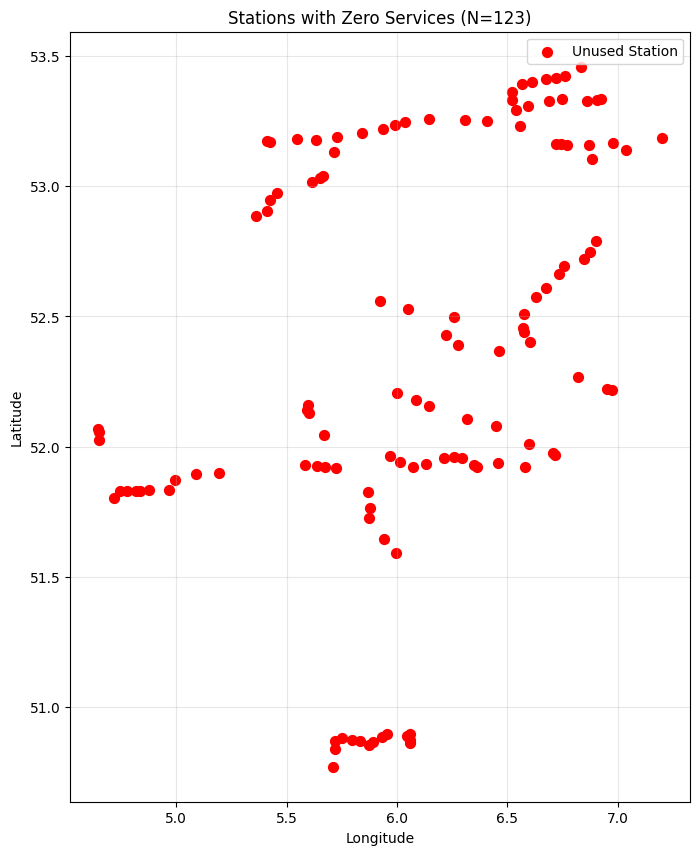

In [ ]:
# --- Cell: Data Quality - Stations without Services ---

print("Analyzing Station Coverage...")

# Logic: Take ALL stations, join to services, count matches. 
# We filter for 'service_count = 0'.
orphan_stations_query = """
    SELECT 
        st.code, 
        st.name_long, 
        st.type, 
        st.country,
        st.geo_lat, 
        st.geo_lng,
        COUNT(s.service_id) as total_services
    FROM stations st
    LEFT JOIN services s 
      ON st.code = s.station_code
    WHERE st.country = 'NL' -- Focus on Dutch stations first
    GROUP BY 1, 2, 3, 4, 5, 6
    HAVING total_services = 0
    ORDER BY st.type, st.name_long
"""

df_unused_stations = con.execute(orphan_stations_query).df()

if len(df_unused_stations) > 0:
    print(f"⚠️ Found {len(df_unused_stations)} stations with NO services:")
    display(df_unused_stations)
    
    import matplotlib.pyplot as plt
    
    plt.figure(figsize=(8, 10))
  
    # Plot the unused ones in Red
    plt.scatter(df_unused_stations['geo_lng'], df_unused_stations['geo_lat'], c='red', s=50, label='Unused Station')
    plt.title(f"Stations with Zero Services (N={len(df_unused_stations)})")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig(EDA_folder / 'eda_stations_noservices.png', bbox_inches='tight', dpi=300)
    plt.show()
else:
    print("✅ All Dutch stations in the dataset have at least one service.")

In [ ]:
# # --- Cell: Data Quality - Stations without Services ---

# print("Analyzing Station Coverage...")

# # Logic: Take ALL stations, join to services, count matches. 
# # We filter for 'service_count = 0'.
# orphan_stations_query = """
#     SELECT 
#         st.code, 
#         st.name_long, 
#         st.type, 
#         st.country,
#         st.geo_lat, 
#         st.geo_lng,
#         COUNT(s.service_id) as total_services
#     FROM stations st
#     LEFT JOIN services s 
#       ON st.code = s.station_code
#     WHERE st.country = 'NL' -- Focus on Dutch stations first
#     GROUP BY 1, 2, 3, 4, 5, 6
#     HAVING total_services = 0
#     ORDER BY st.type, st.name_long
# """

# df_unused_stations = con.execute(orphan_stations_query).df()

# if len(df_unused_stations) > 0:
#     print(f"⚠️ Found {len(df_unused_stations)} stations with NO services:")
#     display(df_unused_stations)
    
#     # Plot them to see where they are
#     import matplotlib.pyplot as plt
    
#     plt.figure(figsize=(8, 10))
#     # Plot valid stations in grey (small)
#     # We need a separate query for this, or just assume the context of previous plots
    
#     # Plot the unused ones in Red
#     plt.scatter(df_unused_stations['geo_lng'], df_unused_stations['geo_lat'], c='red', s=50, label='Unused Station')
#     plt.title(f"Stations with Zero Services (N={len(df_unused_stations)})")
#     plt.xlabel("Longitude")
#     plt.ylabel("Latitude")
#     plt.legend()
#     plt.grid(True, alpha=0.3)
#     plt.show()
# else:
#     print("✅ All Dutch stations in the dataset have at least one service.")

Analyzing Station Coverage...
✅ All Dutch stations in the dataset have at least one service.


In [ ]:
# df_unused_stations[df_unused_stations['code'] == 'NA']

,code,name_long,type,country,geo_lat,geo_lng,total_services
22,NA,Nieuw Amsterdam,sneltreinstation,NL,52.718613,6.848611,0


In [ ]:
# df_unused_stations[df_unused_stations['name_long'] == 'Amsterdam Centraal']

,code,name_long,type,country,geo_lat,geo_lng,total_services


In [16]:
valid_stations_query = """
    SELECT DISTINCT code 
    FROM stations
"""
valid_codes_df = con.execute(valid_stations_query).df()
valid_codes_set = set(valid_codes_df['code'])

### Stations in services dataset
We constrain to stations that are present within the services dataset

In [10]:
# --- Cell: Create Adjacency List from Services ---

print("Inferring network connections from train movements...")

# 1. Extract raw connections (A -> B) from the schedule
create_connections_query = """
    CREATE OR REPLACE TABLE inferred_connections AS
    WITH ordered_stops AS (
        SELECT 
            service_id,
            service_date,
            station_code as from_station,
            departure_time,
            
            -- Look ahead to find the NEXT station for this same train
            LEAD(station_code) OVER (
                PARTITION BY service_id, service_date 
                ORDER BY arrival_time ASC
            ) as to_station,
            
            -- Calculate travel time while we are at it
            LEAD(arrival_time) OVER (
                PARTITION BY service_id, service_date 
                ORDER BY arrival_time ASC
            ) as next_arrival_time
            
        FROM services
        WHERE is_cancelled = FALSE -- Only use actual running trains
    )
    SELECT 
        from_station,
        to_station,
        -- Calculate average travel time for this link
        AVG(DATE_DIFF('minute', departure_time, next_arrival_time)) as avg_travel_min,
        COUNT(*) as frequency -- How often do trains drive this link?
    FROM ordered_stops
    WHERE to_station IS NOT NULL -- Remove the last stop (has no destination)
    GROUP BY from_station, to_station
    ORDER BY frequency DESC
"""

con.execute(create_connections_query)

# --- Verification ---
print("✅ Table 'inferred_connections' created.")
display(con.execute("SELECT * FROM inferred_connections LIMIT 10").df())

Inferring network connections from train movements...
✅ Table 'inferred_connections' created.


,from_station,to_station,avg_travel_min,frequency
0,ASS,ASD,5.953886,744423
1,ASDZ,SHL,6.021003,417793
2,SHL,HFD,4.215543,340155
3,ASD,ASS,5.687291,307502
4,ASS,ZD,6.621522,301313
5,ZD,ASS,6.115427,301086
6,UTO,UT,4.092024,275714
7,SDM,RTD,4.884739,264967
8,RTB,RTD,3.001184,263528
9,ASDM,ASD,5.983894,262272


In [11]:
display(con.execute("SELECT * FROM inferred_connections ORDER BY frequency ASC LIMIT 10").df())

,from_station,to_station,avg_travel_min,frequency
0,HLM,RTD,58.0,1
1,HAD,BGN,110.0,1
2,ASS,ASB,-1.0,1
3,HIL,GVC,33.0,1
4,SDM,ASB,85.0,1
5,KLP,ASA,41.0,1
6,DB,WF,0.0,1
7,WF,KLP,8.0,1
8,ETN,HT,44.0,1
9,CL,WT,NaN,1


In [12]:
# --- Cell: Count Rows and Unique Connections ---

print("Calculating network statistics...")

stats_query = """
    SELECT 
        -- 1. How many rows in the table?
        COUNT(*) as row_count,
        
        -- 2. How many unique From-To pairs? (Should match row_count)
        COUNT(DISTINCT from_station || '-' || to_station) as unique_edges,
        
        -- 3. Total volume of traffic (sum of all frequencies)
        SUM(frequency) as total_train_trips
    FROM inferred_connections
"""

stats = con.execute(stats_query).df()

display(stats)

# Logic check
if stats['row_count'][0] == stats['unique_edges'][0]:
    print("✅ Verified: Every row represents a unique connection.")
else:
    print("⚠️ Mismatch found (Unexpected duplicates).")
    

Calculating network statistics...


,row_count,unique_edges,total_train_trips
0,2788,2788,63399850.0


✅ Verified: Every row represents a unique connection.


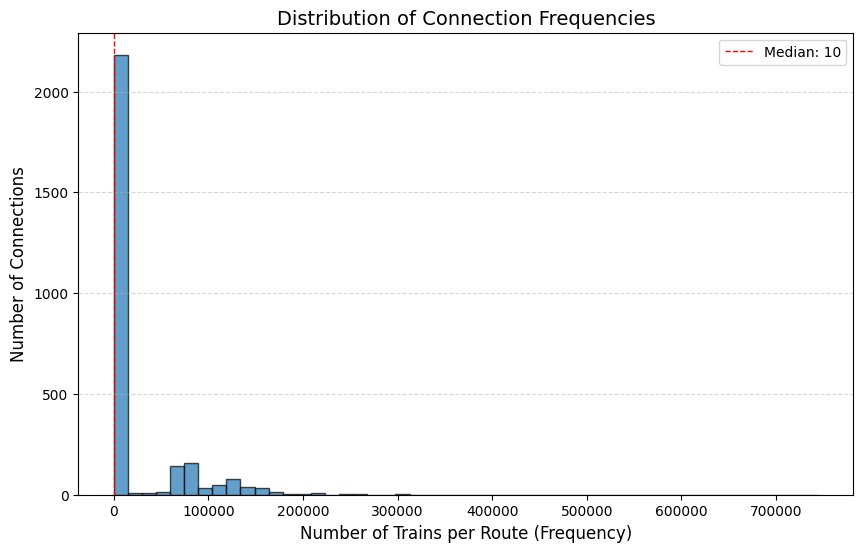

Frequency Statistics:
count      2788.000000
mean      22740.261836
std       49341.913109
min           1.000000
25%           2.000000
50%          10.000000
75%        2106.750000
max      744423.000000
Name: frequency, dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Get the data from DuckDB
# We only need the frequency column for this specific plot
df_freq = con.execute("SELECT frequency FROM inferred_connections").df()

# 2. Plot the Histogram
plt.figure(figsize=(10, 6))

# 'bins=50' splits the data into 50 buckets. Adjust this if you want more/less detail.
plt.hist(df_freq['frequency'], bins=50, color='#1f77b4', edgecolor='black', alpha=0.7)

plt.title('Distribution of Connection Frequencies', fontsize=14)
plt.xlabel('Number of Trains per Route (Frequency)', fontsize=12)
plt.ylabel('Number of Connections', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Add a vertical line for the median
median_freq = df_freq['frequency'].median()
plt.axvline(median_freq, color='red', linestyle='dashed', linewidth=1, label=f'Median: {median_freq:.0f}')
plt.legend()

plt.savefig('frequency_distribution.png')
plt.show()

# 3. Print Summary Stats
print("Frequency Statistics:")
print(df_freq['frequency'].describe())

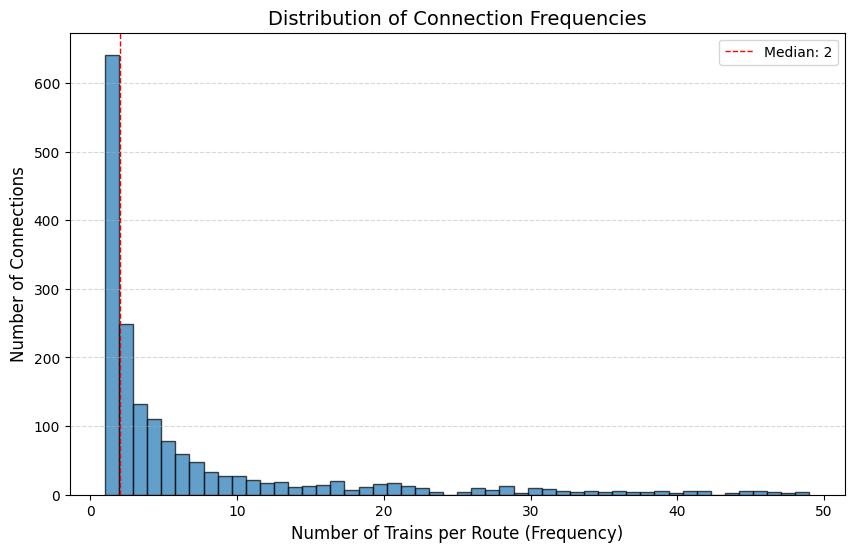

Frequency Statistics:
count    1730.000000
mean        6.765318
std         9.783685
min         1.000000
25%         1.000000
50%         2.000000
75%         7.000000
max        49.000000
Name: frequency, dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Get the data from DuckDB
# We only need the frequency column for this specific plot
df_freq = con.execute("SELECT frequency FROM inferred_connections WHERE frequency < 50").df()

# 2. Plot the Histogram
plt.figure(figsize=(10, 6))

# 'bins=50' splits the data into 50 buckets. Adjust this if you want more/less detail.
plt.hist(df_freq['frequency'], bins=50, color='#1f77b4', edgecolor='black', alpha=0.7)

plt.title('Distribution of Connection Frequencies', fontsize=14)
plt.xlabel('Number of Trains per Route (Frequency)', fontsize=12)
plt.ylabel('Number of Connections', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Add a vertical line for the median
median_freq = df_freq['frequency'].median()
plt.axvline(median_freq, color='red', linestyle='dashed', linewidth=1, label=f'Median: {median_freq:.0f}')
plt.legend()

# plt.savefig('frequency_distribution.png')
plt.show()

# 3. Print Summary Stats
print("Frequency Statistics:")
print(df_freq['frequency'].describe())

In [13]:
# --- Cell: Count Unique Stations in Network ---

print("Analyzing unique stations in the connection network...")

station_counts_query = """
    SELECT 
        -- Count unique origins
        COUNT(DISTINCT from_station) as unique_origins,
        
        -- Count unique destinations
        COUNT(DISTINCT to_station) as unique_destinations,
        
        -- Count TOTAL unique stations (Union of both)
        (SELECT COUNT(DISTINCT station_code) 
         FROM (
             SELECT from_station as station_code FROM inferred_connections
             UNION 
             SELECT to_station as station_code FROM inferred_connections
         )
        ) as total_active_stations
    FROM inferred_connections
"""

display(con.execute(station_counts_query).df())

Analyzing unique stations in the connection network...


,unique_origins,unique_destinations,total_active_stations
0,295,303,306


Check missing total active stations from stations dataset (as we retrieved the weather data based on the stations dataset)

In [15]:
# --- Cell: Data Integrity Check (Active vs. Known Stations) ---

print("Verifying that all active stations within services exist in the 'stations' dataset...")

missing_stations_query = """
    WITH active_stations AS (
        -- Get all unique stations from the connections (both origins and destinations)
        SELECT DISTINCT from_station as code FROM inferred_connections
        UNION 
        SELECT DISTINCT to_station as code FROM inferred_connections
    )
    SELECT 
        a.code as unknown_station_code,
        -- Let's see how often this unknown station appears to judge impact
        (SELECT COUNT(*) FROM inferred_connections WHERE from_station = a.code OR to_station = a.code) as frequency
    FROM active_stations a
    LEFT JOIN stations s ON a.code = s.code
    WHERE s.code IS NULL -- The mismatch filter
    ORDER BY frequency DESC
"""

missing_stations = con.execute(missing_stations_query).df()

if missing_stations.empty:
    print("✅ Success: All active stations are present in the 'stations' dataset.")
else:
    print(f"⚠️ Warning: Found {len(missing_stations)} stations in the schedule that are missing from 'stations' table!")
    print("These 'ghost' stations will likely have missing coordinates:")
    display(missing_stations)

Verifying that all active stations within services exist in the 'stations' dataset...
⚠️ Warning: Found 38 stations in the schedule that are missing from 'stations' table!
These 'ghost' stations will likely have missing coordinates:


,unknown_station_code,frequency
0,ATW,13
1,BSPD,10
2,NDKP,10
3,DTZ,9
4,BERCH,9
5,RHEINE,8
6,MECH,8
7,HANN,8
8,FBNL,7
9,BRUSN,6


Check missing total active stations from connections dataset

In [ ]:
# # --- Cell: Check for Orphaned Stations ---

# print("Checking for stations in the list that have NO connections...")

# orphaned_query = """
#     SELECT 
#         s.code, 
#         s.full_name, 
#         s.station_type,
#         s.is_junction
#     FROM stations s
#     WHERE s.code NOT IN (
#         -- Get the list of all stations that actually have traffic
#         SELECT DISTINCT from_station FROM inferred_connections
#         UNION 
#         SELECT DISTINCT to_station FROM inferred_connections
#     )
#     ORDER BY s.station_type, s.code
# """

# orphaned_df = con.execute(orphaned_query).df()

# if orphaned_df.empty:
#     print("✅ All stations in your reference list have active connections.")
# else:
#     print(f"⚠️ Found {len(orphaned_df)} orphaned stations (No trains detected).")
#     display(orphaned_df)

Checking for stations in the list that have NO connections...


BinderException: Binder Error: Table "s" does not have a column named "full_name"

Candidate bindings: : "uic"

LINE 4:         s.full_name, 
                ^

### Missing days check

In [ ]:
# --- Cell: Time Range & Coverage Check ---

print("1. Global Time Range:")
range_query = """
    SELECT 
        MIN(arrival_time) as global_start,
        MAX(arrival_time) as global_end,
        date_diff('day', MIN(arrival_time), MAX(arrival_time)) as total_days_span
    FROM services
"""
display(con.execute(range_query).df())

print("\n2. Monthly Coverage (Check for Gaps):")
coverage_query = """
    SELECT 
        strftime(arrival_time, '%Y-%m') as year_month,
        COUNT(*) as total_services,
        COUNT(DISTINCT station_code) as active_stations
    FROM services
    WHERE arrival_time IS NOT NULL
    GROUP BY 1
    ORDER BY 1
"""
display(con.execute(coverage_query).df())

1. Global Time Range:


,global_start,global_end,total_days_span
0,2019-01-01 02:12:00+01:00,2025-01-01 02:51:00+01:00,2192



2. Monthly Coverage (Check for Gaps):


,year_month,total_services,active_stations
0,2019-01,1080537,247
1,2019-02,979056,248
2,2019-03,1069829,247
3,2019-04,1034658,247
4,2019-05,1075485,247
...,...,...,...
68,2024-09,1028280,255
69,2024-10,1063111,253
70,2024-11,1033282,250
71,2024-12,1059295,253


In [ ]:
# --- Cell: Data Integrity Check (Missing Days) ---

print("Checking for missing dates in the timeline...")

# 1. SQL to find missing days
# We generate a full sequence of days from MIN to MAX, then find which ones don't exist in 'services'.
gap_query = """
    WITH range AS (
        -- 1. Get the start and end of the dataset
        SELECT MIN(service_date) as start_date, MAX(service_date) as end_date
        FROM services
    ),
    full_calendar AS (
        -- 2. Generate every single day between start and end
        SELECT CAST(unnest(generate_series(start_date, end_date, INTERVAL 1 DAY)) AS DATE) as calendar_day
        FROM range
    ),
    actual_days AS (
        -- 3. Get the days we actually have data for
        SELECT DISTINCT service_date 
        FROM services
    )
    -- 4. Find days in calendar that are NOT in actual_days
    SELECT calendar_day as missing_date
    FROM full_calendar
    LEFT JOIN actual_days ON full_calendar.calendar_day = actual_days.service_date
    WHERE actual_days.service_date IS NULL
    ORDER BY 1
"""

df_gaps = con.execute(gap_query).df()

# 2. Report Results
total_days = con.execute("SELECT COUNT(DISTINCT service_date) FROM services").fetchone()[0]
missing_count = len(df_gaps)

print(f"Total active days in dataset: {total_days}")
print(f"Total missing days (gaps):    {missing_count}")

if missing_count > 0:
    print("\n⚠️ WARNING: The following dates have ZERO service records:")
    # Print first 20 to avoid spamming if there's a huge gap
    print(df_gaps.head(20))
    
    # Visualizing the gap
    plt.figure(figsize=(12, 2))
    plt.scatter(df_gaps['missing_date'], [1]*missing_count, color='red', marker='x', s=100, label='Missing Data')
    plt.yticks([])
    plt.title("Timeline of Missing Data")
    plt.xlabel("Date")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("\n✅ Success: The dataset is continuous. No missing days found.")

Checking for missing dates in the timeline...
Total active days in dataset: 2192
Total missing days (gaps):    0

✅ Success: The dataset is continuous. No missing days found.


### Missing hours check

Scanning hourly data density...


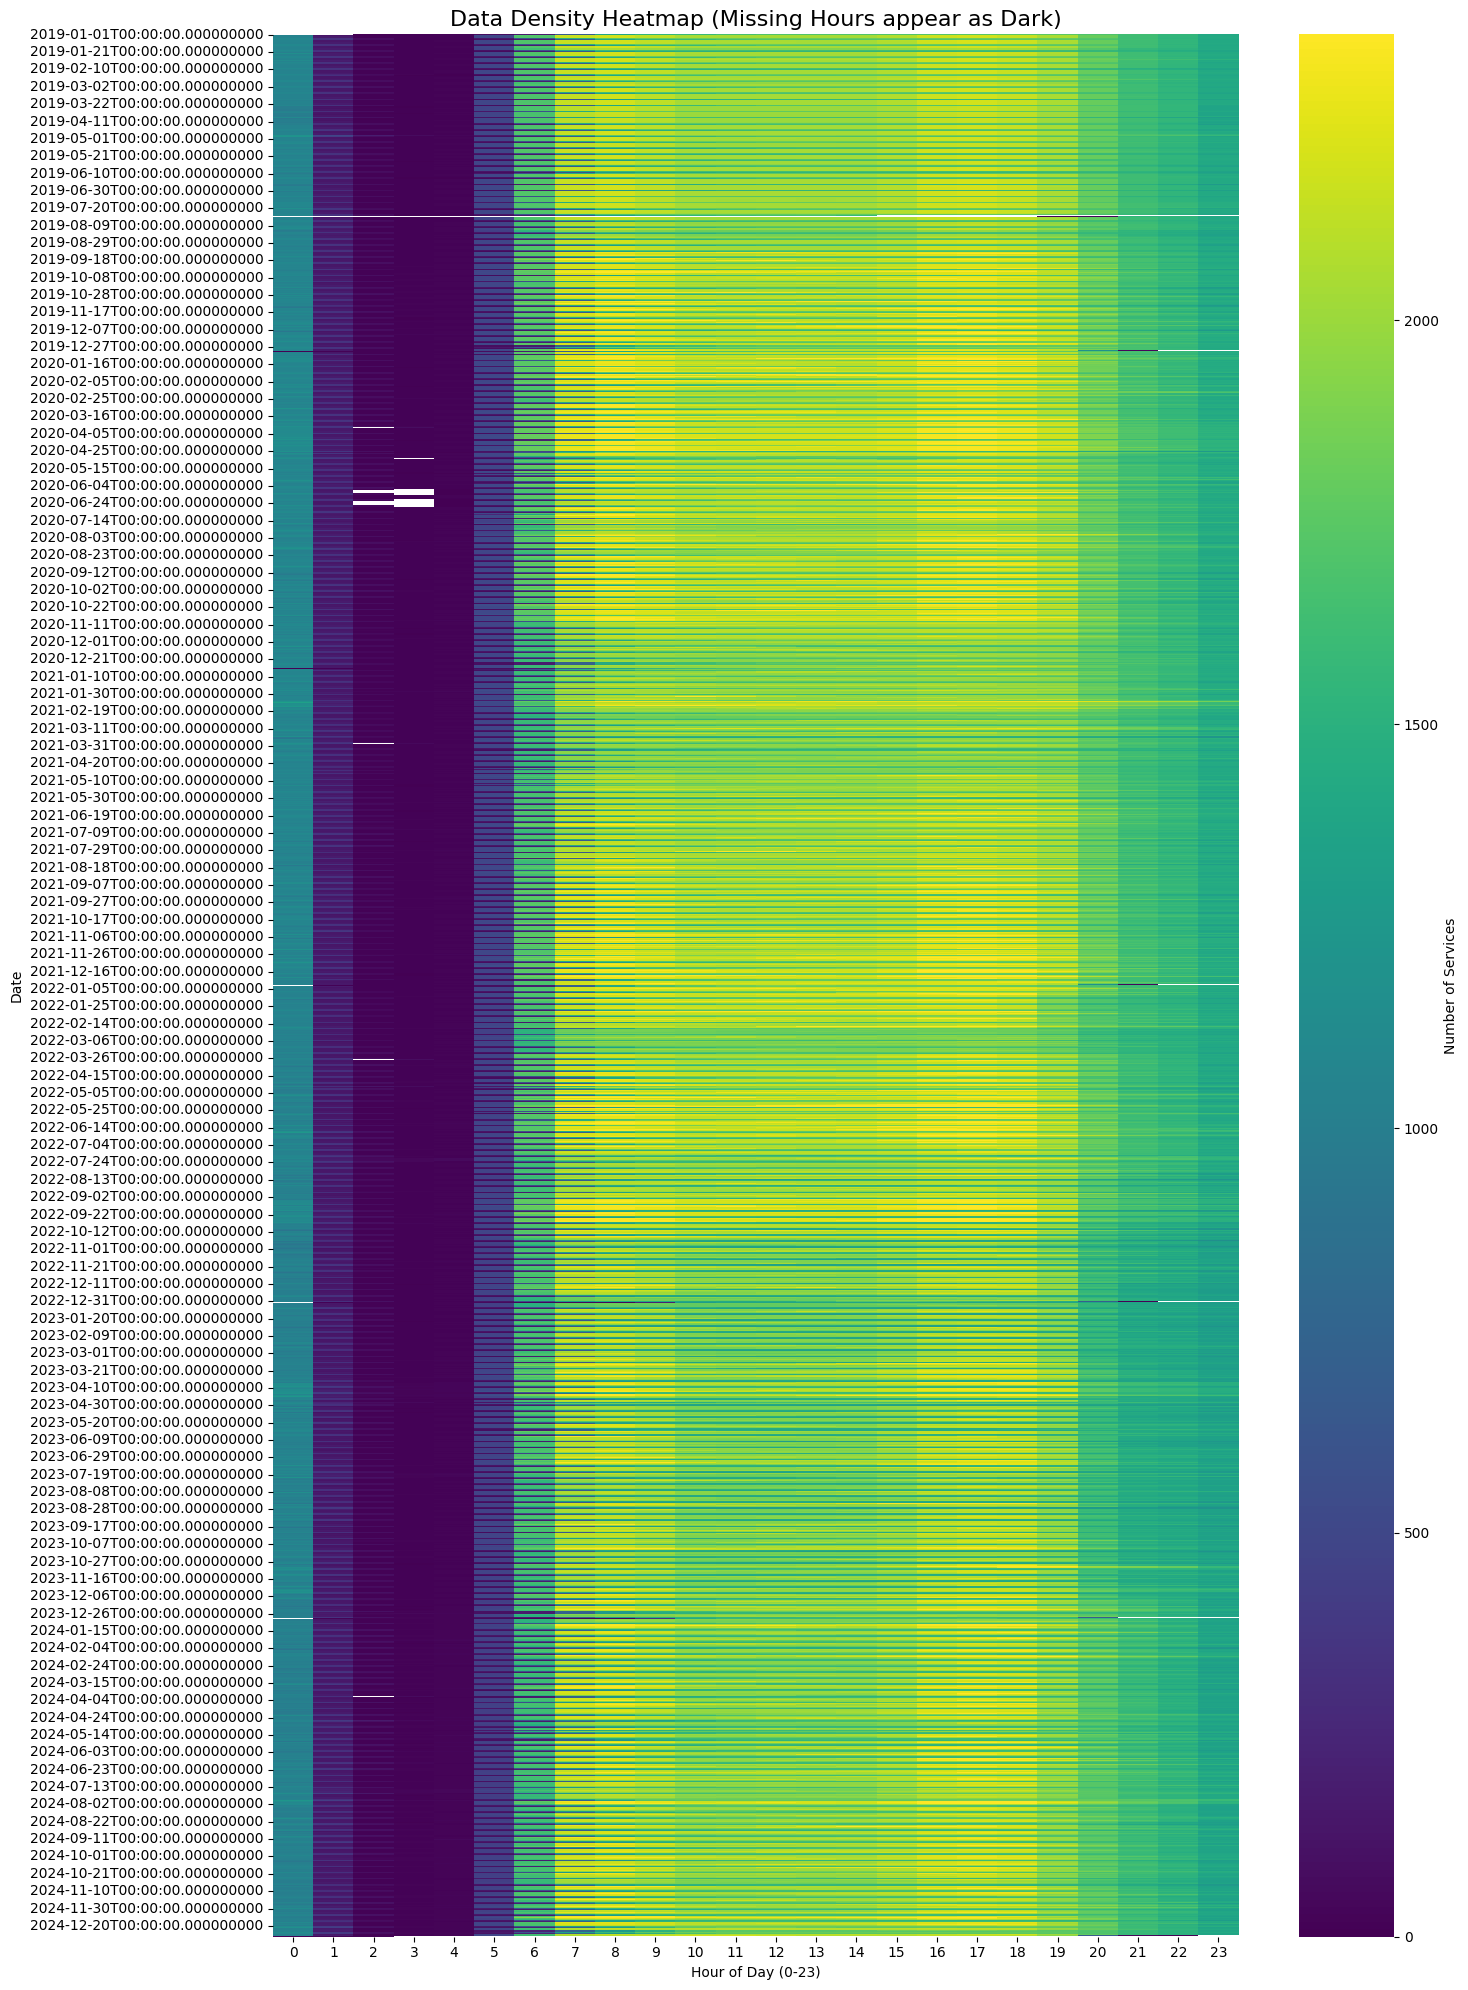

Data Completeness Score: 99.82%
Total Missing/Empty Hours: 95 out of 52632


In [45]:
# --- Cell: Hourly Data Integrity Check (Heatmap) ---

print("Scanning hourly data density...")

# 1. SQL: Count rows per Date + Hour
# We group by Date and Hour to see "How many trains ran in this specific hour?"
density_query = """
    SELECT 
        CAST(arrival_time AS DATE) as service_date,
        HOUR(arrival_time) as hour_of_day,
        COUNT(*) as record_count
    FROM services
    WHERE arrival_time IS NOT NULL
    GROUP BY 1, 2
"""
df_density = con.execute(density_query).df()

# 2. Pivot for Heatmap
# Index = Date, Columns = Hour (0-23), Values = Record Count
pivot_density = df_density.pivot(index='service_date', columns='hour_of_day', values='record_count')

# 3. Reindex to ensure ALL dates are present (even empty ones)
# This fills the "missing days" we found earlier with NaNs so they show up as white gaps
all_dates = pd.date_range(start=pivot_density.index.min(), end=pivot_density.index.max(), freq='D')
pivot_density = pivot_density.reindex(all_dates)

# 4. Plotting
# We might need to downsample if you have 10 years of data (3650 rows is a lot for a heatmap)
# If the plot is too tall, we slice it or resample.
plt.figure(figsize=(15, 20)) # Tall plot to fit years
sns.heatmap(
    pivot_density, 
    cmap="viridis", 
    cbar_kws={'label': 'Number of Services'},
    vmin=0, 
    vmax=pivot_density.quantile(0.95).max() # Cap color scale at 95th percentile to handle outliers
)

plt.title("Data Density Heatmap (Missing Hours appear as Dark)", fontsize=16)
plt.xlabel("Hour of Day (0-23)")
plt.ylabel("Date")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 5. Report Total Empty Hours
# An "Empty Hour" is a cell in this table that is NaN or 0
total_hours_possible = pivot_density.size
missing_hours_count = pivot_density.isna().sum().sum() + (pivot_density == 0).sum().sum()
completeness_pct = 100 * (1 - (missing_hours_count / total_hours_possible))

print(f"Data Completeness Score: {completeness_pct:.2f}%")
print(f"Total Missing/Empty Hours: {missing_hours_count} out of {total_hours_possible}")

### Double checking minutes for recorded Arrival & Departure timestamps -> can ignore if we aggregate by hour 
Double check whether the timestamps recorded are actually rounded to minutes or include exact seconds

In [6]:
# --- Cell: Data Precision Check (Seconds vs Minutes) ---

print("Checking timestamp precision...")

precision_query = """
    SELECT 
        'Arrival Time' as column_name,
        COUNT(*) as total_rows,
        -- Count how many have exactly 00 seconds
        SUM(CASE WHEN SECOND(arrival_time) = 0 THEN 1 ELSE 0 END) as zero_seconds_count,
        -- Count how many have non-zero seconds (e.g., 14:05:33)
        SUM(CASE WHEN SECOND(arrival_time) > 0 THEN 1 ELSE 0 END) as specific_seconds_count
    FROM services
    WHERE arrival_time IS NOT NULL
    
    UNION ALL
    
    SELECT 
        'Departure Time',
        COUNT(*),
        SUM(CASE WHEN SECOND(departure_time) = 0 THEN 1 ELSE 0 END),
        SUM(CASE WHEN SECOND(departure_time) > 0 THEN 1 ELSE 0 END)
    FROM services
    WHERE departure_time IS NOT NULL
"""

df_precision = con.execute(precision_query).df()

# Calculate Percentage
df_precision['% Rounded (00s)'] = (df_precision['zero_seconds_count'] / df_precision['total_rows']) * 100
df_precision['% Exact (>00s)'] = (df_precision['specific_seconds_count'] / df_precision['total_rows']) * 100

print(df_precision[['column_name', '% Rounded (00s)', '% Exact (>00s)']])

# Interpretation Logic
if df_precision['specific_seconds_count'].sum() == 0:
    print("\nResult: 🔒 All timestamps are ROUNDED to the minute (XX:XX:00).")
    print("Implication: You could theoretically join using '=', but '>=' is still safer for interval logic.")
else:
    print("\nResult: ⏱️ Timestamps contain EXACT SECONDS.")
    print("Implication: You MUST use inequality (>=) for joins. Exact matching (=) will fail 99% of the time.")

Checking timestamp precision...
      column_name  % Rounded (00s)  % Exact (>00s)
0    Arrival Time        99.983777        0.016223
1  Departure Time        99.984386        0.015614

Result: ⏱️ Timestamps contain EXACT SECONDS.
Implication: You MUST use inequality (>=) for joins. Exact matching (=) will fail 99% of the time.


In [9]:
# --- Cell: Inspect Exact Second Timestamps ---

print("Fetching full records that have non-zero seconds...")

# Select rows where either Arrival OR Departure has seconds > 0
exact_seconds_query = """
    SELECT *
    FROM services
    WHERE (arrival_time IS NOT NULL AND SECOND(arrival_time) > 0)
        OR (departure_time IS NOT NULL AND SECOND(departure_time) > 0)
    -- LIMIT 10
"""

df_exact_seconds = con.execute(exact_seconds_query).df()

if len(df_exact_seconds) > 0:
    print(f"Found {len(df_exact_seconds)} example records with exact seconds:")
    display(df_exact_seconds)
else:
    print("Result: No records found with non-zero seconds.")
    print("All timestamps in the dataset are rounded to the minute (XX:XX:00).")

Fetching full records that have non-zero seconds...
Found 15272 example records with exact seconds:


,service_id,service_date,train_type,station_code,station_name,arrival_time,arrival_delay_min,is_cancelled,departure_time
0,760282,2019-01-04,Intercity,ZLW,Lage Zwaluwe,2019-01-04 17:48:16+01:00,4,False,NaT
1,770470,2019-01-06,Intercity,PT,Putten,2019-01-06 15:47:58+01:00,0,False,NaT
2,770660,2019-01-06,Intercity,HGV,Hoogeveen,2019-01-06 15:51:05+01:00,1,False,NaT
3,779008,2019-01-07,Intercity,WF,Wolfheze,2019-01-08 00:25:07+01:00,1,False,2019-01-08 00:25:07+01:00
4,811850,2019-01-13,Intercity,WD,Woerden,2019-01-13 11:59:09+01:00,0,False,NaT
...,...,...,...,...,...,...,...,...,...
15267,14260947,2024-08-25,Sprinter,HWZB,Halfweg-Zwanenburg,2024-08-26 01:21:11+02:00,0,False,2024-08-26 01:21:11+02:00
15268,14260947,2024-08-25,Sprinter,ASS,Amsterdam Sloterdijk,2024-08-26 01:26:49+02:00,0,False,2024-08-26 01:26:49+02:00
15269,14260947,2024-08-25,Sprinter,ASD,Amsterdam Centraal,2024-08-26 01:31:47+02:00,0,False,NaT
15270,14266158,2024-08-23,Sprinter,ASD,Amsterdam Centraal,NaT,<NA>,<NA>,2024-08-23 20:29:22+02:00


### Network level 

Class balance arrival delay of all services: base line for binary classification

Summarizing Dataset...
   total_stops               first_train                last_train  \
0     83492358 2019-01-01 02:12:00+01:00 2025-01-01 02:51:00+01:00   

   global_avg_delay  
0          0.702454  


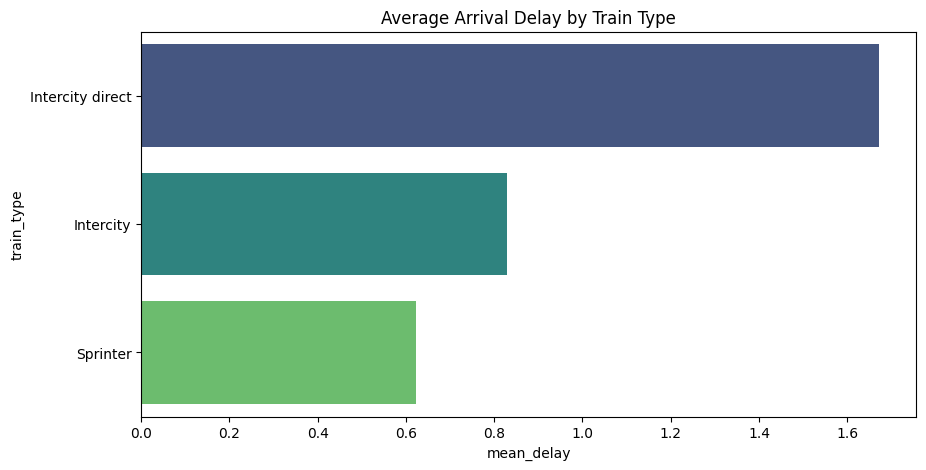

Calculating Class Balance...
                     status     count  percentage
0  No Delay (On Time/Early)  57789434   76.601562
1                   Delayed  17652153   23.398438


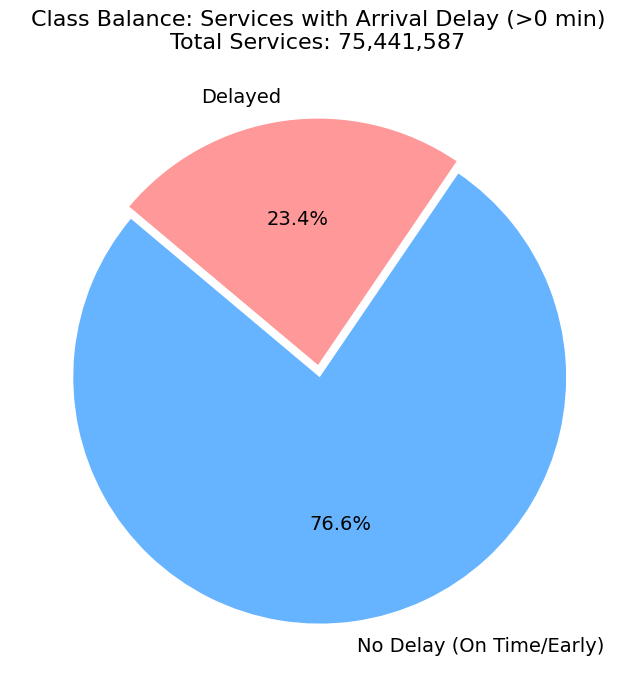

In [31]:
# --- A. General Summary ---
print("Summarizing Dataset...")
summary = con.execute("""
    SELECT 
        COUNT(*) as total_stops,
        MIN(arrival_time) as first_train,
        MAX(arrival_time) as last_train,
        AVG(arrival_delay_min) as global_avg_delay
    FROM services
""").df()
print(summary)

# # --- B. Delay Heatmap (Day of Week vs Hour) ---
# print("\nGenerating Heatmap Data...")
# heatmap_query = """
#     SELECT 
#         DAYOFWEEK(arrival_time) as day_idx, -- 1=Monday, 7=Sunday
#         HOUR(arrival_time) as hour_idx,
#         AVG(arrival_delay_min) as mean_delay
#     FROM services
#     WHERE arrival_time IS NOT NULL
#     GROUP BY 1, 2
# """
# df_heat = con.execute(heatmap_query).df()
# pivot_heat = df_heat.pivot(index='day_idx', columns='hour_idx', values='mean_delay')

# plt.figure(figsize=(12, 6))
# sns.heatmap(pivot_heat, cmap="RdYlGn_r", center=5, annot=False)
# plt.title("Average Delay (Minutes) by Day and Hour")
# plt.xlabel("Hour of Day")
# plt.ylabel("Day of Week (1=Mon)")
# plt.show()

# --- C. Delays per Train Type ---
df_type = con.execute("""
    SELECT train_type, AVG(arrival_delay_min) as mean_delay, COUNT(*) as count
    FROM services
    GROUP BY 1 HAVING count > 1000
    ORDER BY 2 DESC
""").df()

plt.figure(figsize=(10, 5))
sns.barplot(data=df_type, x='mean_delay', y='train_type', palette="viridis", hue='train_type', legend=False)
plt.title("Average Arrival Delay by Train Type")
plt.show()


# --- Cell: Class Balance (Delayed vs No Delay) ---

print("Calculating Class Balance...")

# 1. SQL Query to categorize and count
# 'arrival_delay_min' > 0 means delayed.
balance_query = """
    SELECT 
        CASE 
            WHEN arrival_delay_min > 0 THEN 'Delayed'
            ELSE 'No Delay (On Time/Early)'
        END as status,
        COUNT(*) as count
    FROM services
    WHERE arrival_delay_min IS NOT NULL
    GROUP BY 1
    ORDER BY 2 DESC
"""

df_balance = con.execute(balance_query).df()

# 2. Calculate Percentages
total_services = df_balance['count'].sum()
df_balance['percentage'] = (df_balance['count'] / total_services) * 100

print(df_balance)

# 3. Plotting the Pie Chart
plt.figure(figsize=(8, 8))

# Define colors: Green for no delay, Red for delayed
colors = ['#ff9999' if status == 'Delayed' else '#66b3ff' for status in df_balance['status']]

plt.pie(
    df_balance['count'], 
    labels=df_balance['status'], 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=colors,
    explode=(0.05, 0), # Slightly "explode" the first slice to emphasize it
    textprops={'fontsize': 14}
)

plt.title(f'Class Balance: Services with Arrival Delay (>0 min)\nTotal Services: {total_services:,}', fontsize=16)
plt.show()

We check the longest period that went by without any delay across the whole train network of NS

In [66]:
# --- Max Time Without Delays (The "Clean Network" Metric) ---
# Logic: We find all timestamps where a delay > 5 min or > 1 occurred.
# We sort them and find the largest gap between two consecutive delay events.

gap_query = """
    WITH severe_delays AS (
        SELECT arrival_time
        FROM services
        WHERE arrival_delay_min > 0 -- Threshold for 'Delay'
        AND arrival_time IS NOT NULL
    ),
    ordered_delays AS (
        SELECT 
            arrival_time, 
            LEAD(arrival_time) OVER (ORDER BY arrival_time) as next_delay_time
        FROM severe_delays
    ),
    gaps AS (
        SELECT 
            arrival_time, 
            date_diff('minute', arrival_time, next_delay_time) as gap_minutes
        FROM ordered_delays
        WHERE next_delay_time IS NOT NULL
    )
    SELECT 
        MAX(gap_minutes) / 60.0 as max_hours_clean,
        AVG(gap_minutes) as avg_minutes_clean
    FROM gaps
"""

gap_query_five_mins = """
    WITH severe_delays AS (
        SELECT arrival_time
        FROM services
        WHERE arrival_delay_min > 5 -- Threshold for 'Delay'
        AND arrival_time IS NOT NULL
    ),
    ordered_delays AS (
        SELECT 
            arrival_time, 
            LEAD(arrival_time) OVER (ORDER BY arrival_time) as next_delay_time
        FROM severe_delays
    ),
    gaps AS (
        SELECT 
            arrival_time, 
            date_diff('minute', arrival_time, next_delay_time) as gap_minutes
        FROM ordered_delays
        WHERE next_delay_time IS NOT NULL
    )
    SELECT 
        MAX(gap_minutes) / 60.0 as max_hours_clean,
        AVG(gap_minutes) as avg_minutes_clean
    FROM gaps
"""

print("Calculating Network Resilience...")
df_gaps = con.execute(gap_query).df()
print(f"Longest period the ENTIRE network ran without any delays (>1m): {df_gaps['max_hours_clean'][0] // 24} days")
df_gaps_five = con.execute(gap_query_five_mins).df()
print(f"Longest period the ENTIRE network ran without any delays (>5m): {df_gaps_five['max_hours_clean'][0] // 24} days")

Calculating Network Resilience...
Longest period the ENTIRE network ran without any delays (>1m): 2.0 days
Longest period the ENTIRE network ran without any delays (>5m): 2.0 days


#### Arrival Delay per Time horizon level (hourly, weekly and per week)


Analyzing Hourly Delays...
Analyzing Daily Delays...
Analyzing Weekly Delays...


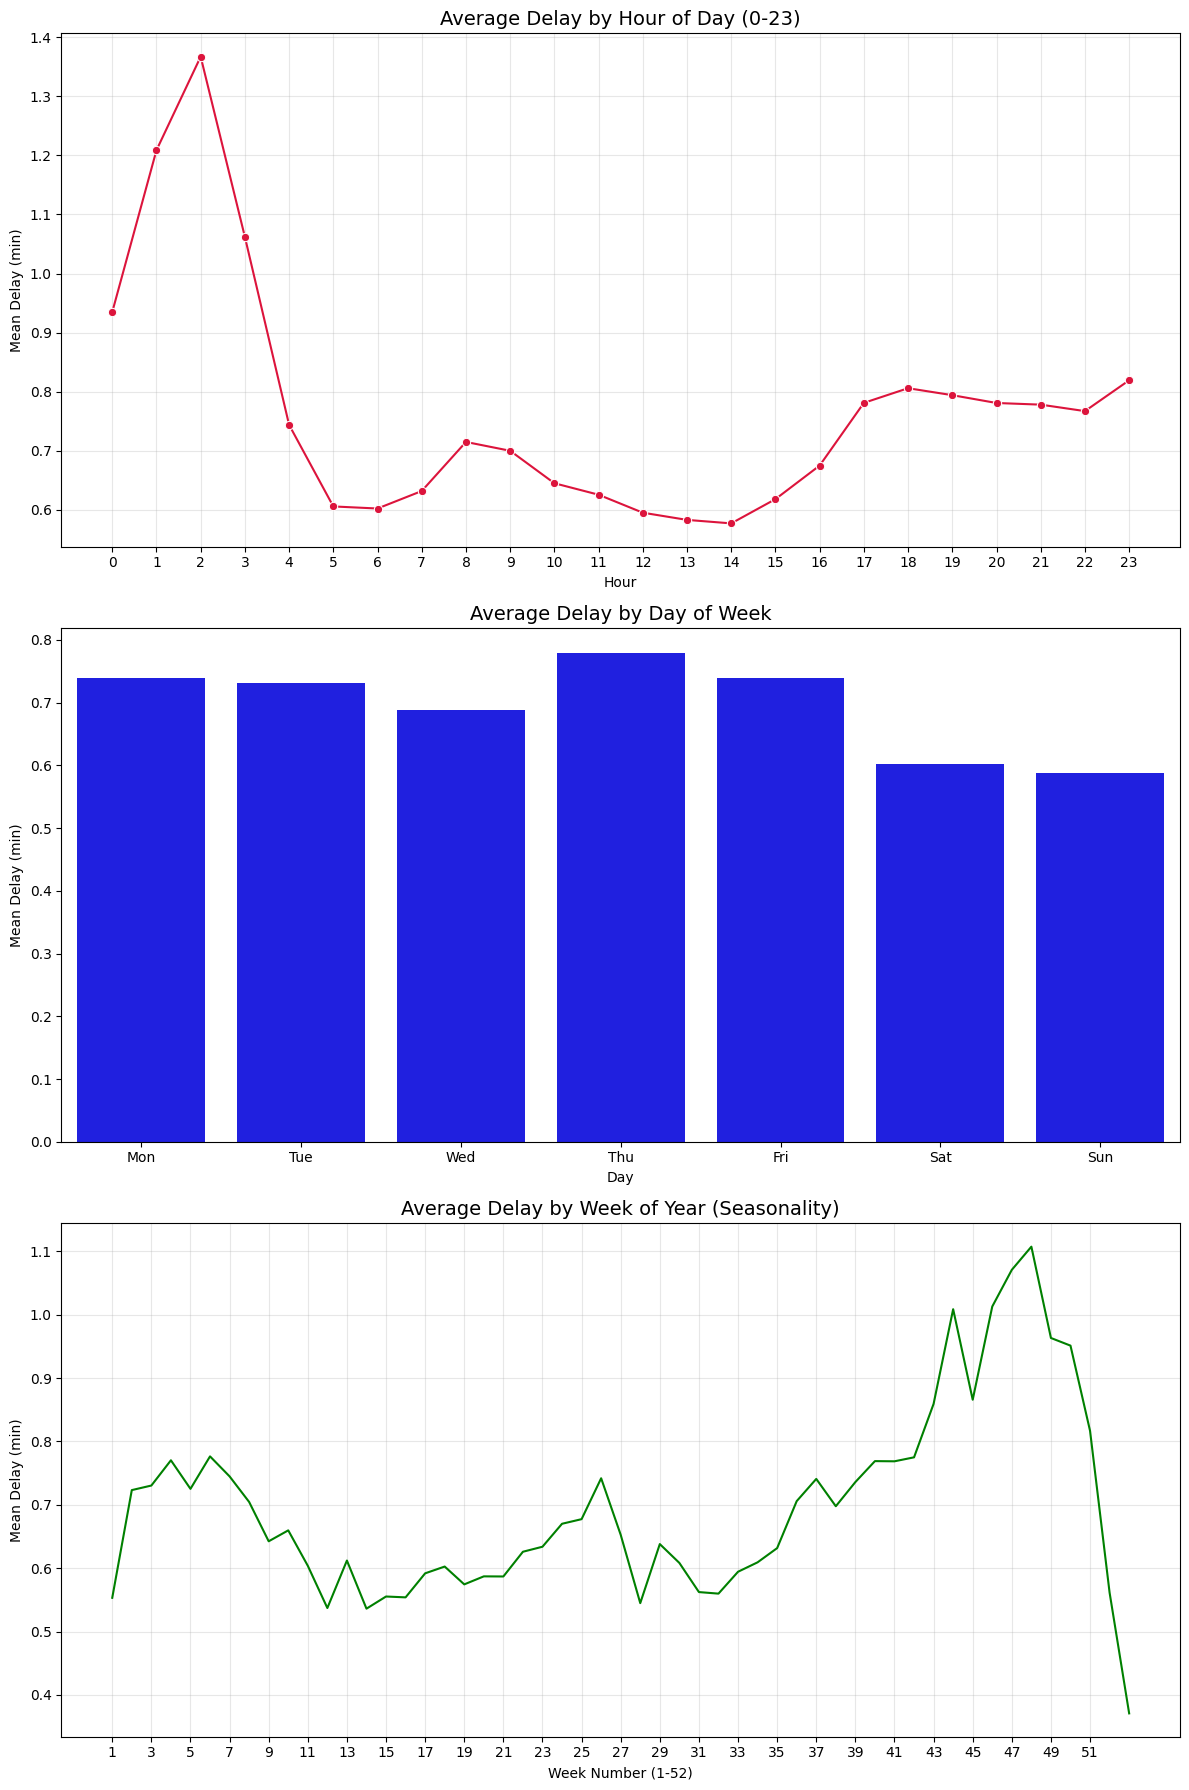

In [33]:
# --- Cell: Temporal Patterns of Delay ---

# 1. Hourly Trend (The "Commuter Curve")
print("Analyzing Hourly Delays...")
hourly_df = con.execute("""
    SELECT 
        HOUR(arrival_time) as hour_of_day,
        AVG(arrival_delay_min) as mean_delay,
        COUNT(*) as traffic_volume
    FROM services
    WHERE arrival_time IS NOT NULL
    GROUP BY 1
    ORDER BY 1
""").df()

# 2. Daily Trend (Day of Week)
print("Analyzing Daily Delays...")
daily_df = con.execute("""
    SELECT 
        ISODOW(arrival_time) as day_idx,     
        CASE ISODOW(arrival_time)
            WHEN 1 THEN 'Mon' WHEN 2 THEN 'Tue' WHEN 3 THEN 'Wed'
            WHEN 4 THEN 'Thu' WHEN 5 THEN 'Fri' WHEN 6 THEN 'Sat' WHEN 7 THEN 'Sun'
        END as day_name,
        AVG(arrival_delay_min) as mean_delay
    FROM services
    WHERE arrival_time IS NOT NULL
    GROUP BY 1, 2
    ORDER BY 1
""").df()

# 3. Weekly Trend (Seasonal Seasonality)
print("Analyzing Weekly Delays...")
weekly_df = con.execute("""
    SELECT 
        WEEK(arrival_time) as week_number,
        AVG(arrival_delay_min) as mean_delay
    FROM services
    WHERE arrival_time IS NOT NULL
    GROUP BY 1
    ORDER BY 1
""").df()

# --- Plotting ---
fig, axes = plt.subplots(3, 1, figsize=(12, 18))

# Plot 1: Hourly
sns.lineplot(data=hourly_df, x='hour_of_day', y='mean_delay', ax=axes[0], marker='o', color='crimson')
axes[0].set_title('Average Delay by Hour of Day (0-23)', fontsize=14)
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Mean Delay (min)')
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(range(0, 24))

# Plot 2: Daily (Day of Week)
sns.barplot(data=daily_df, x='day_name', y='mean_delay', ax=axes[1], color='blue')
axes[1].set_title('Average Delay by Day of Week', fontsize=14)
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Mean Delay (min)')

# Plot 3: Weekly (Yearly Seasonality)
sns.lineplot(data=weekly_df, x='week_number', y='mean_delay', ax=axes[2], color='green')
axes[2].set_title('Average Delay by Week of Year (Seasonality)', fontsize=14)
axes[2].set_xlabel('Week Number (1-52)')
axes[2].set_ylabel('Mean Delay (min)')
axes[2].grid(True, alpha=0.3)
axes[2].set_xticks(range(1, 53, 2)) # Label every 2nd week

plt.tight_layout()
plt.show()

## Disruptions Dataset

This dataset refers to major disruptions recorded by NS (affecting multiple trains/lines)

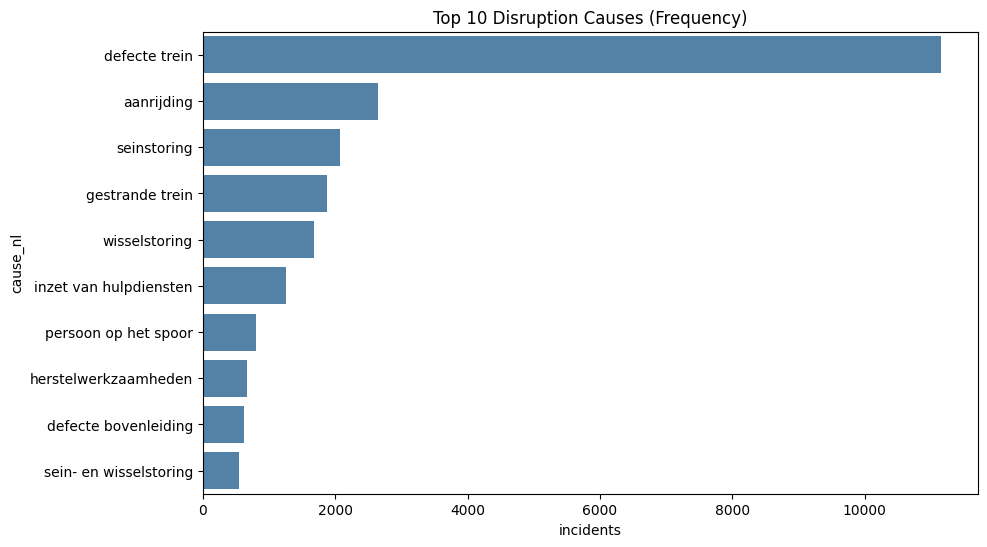

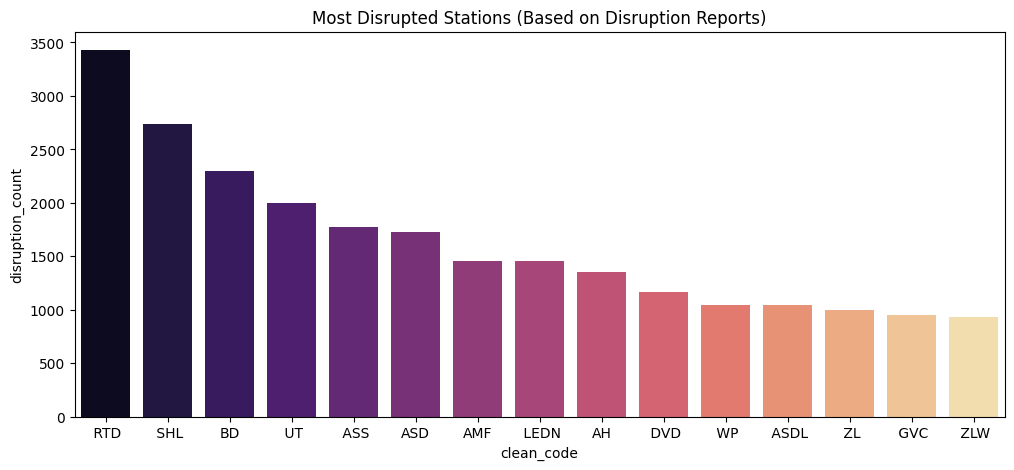

In [34]:
# --- A. Top Disruption Causes ---
df_causes = con.execute("""
    SELECT cause_nl, COUNT(*) as incidents, AVG(duration_minutes) as avg_duration
    FROM disruptions
    WHERE cause_nl IS NOT NULL
    GROUP BY 1
    ORDER BY 2 DESC
    LIMIT 10
""").df()

plt.figure(figsize=(10, 6))
sns.barplot(data=df_causes, x='incidents', y='cause_nl', color='steelblue')
plt.title("Top 10 Disruption Causes (Frequency)")
plt.show()

# --- B. Station Vulnerability (Unnesting the list) ---
df_vuln = con.execute("""
    WITH unpacked AS (
        SELECT UNNEST(station_array) as clean_code, duration_minutes
        FROM disruptions
    )
    SELECT clean_code, COUNT(*) as disruption_count
    FROM unpacked
    WHERE clean_code != ''
    GROUP BY 1
    ORDER BY 2 DESC
    LIMIT 15
""").df()

plt.figure(figsize=(12, 5))
sns.barplot(data=df_vuln, x='clean_code', y='disruption_count', palette="magma", hue='clean_code', legend=False)
plt.title("Most Disrupted Stations (Based on Disruption Reports)")
plt.show()

### Disruptions as % of Services

Missing disruptions

i.e. if disruptions (rdt_id) in services (rdt_id) & Only arrival delay, excl cancellations

Total Disruption Events (rdt_id):  31,163
✅ Matched with Services:           24,128 (77.4%)
⚠️ Missing (No matching trains):    7,035 (22.6%)

Analyzing Missing Disruptions (Events with zero matching trains)...
Total Disruption Events (rdt_id):  31,163
✅ Matched with Services:           24,128 (77.4%)
⚠️ Missing (No matching trains):    7,035 (22.6%)


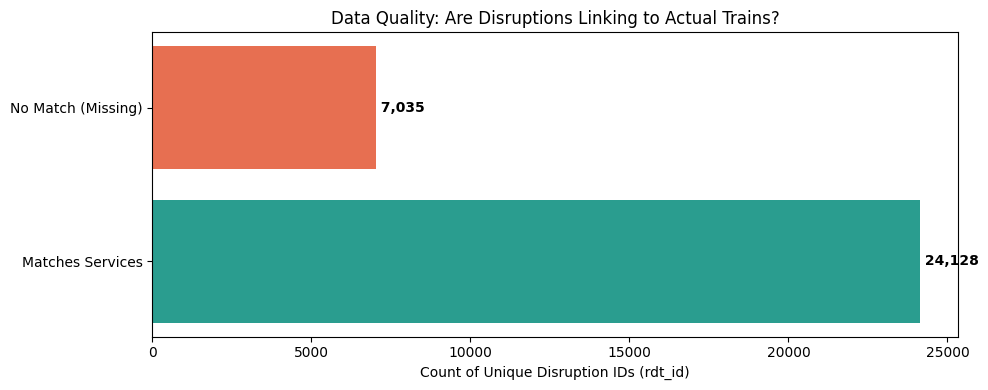


Top Causes of Missing Disruptions (Events that didn't affect any logged train):
          cause_nl  count
0    defecte trein  10697
1       aanrijding   2589
2      seinstoring   1985
3  gestrande trein   1777
4    wisselstoring   1573


In [ ]:
# --- Cell: Missing Disruption Analysis ---
# Checking: Which disruption IDs (rdt_id) have NO matching services?

print("Analyzing Missing Disruptions (Events with zero matching trains)...")

# 1. Prepare Flattened Disruptions (if not already done in previous cells)
con.execute("""
    CREATE OR REPLACE TEMP TABLE flat_disruptions AS
    SELECT 
        rdt_id,
        cause_nl,
        UNNEST(station_array) as station_code,
        start_time,
        end_time
    FROM disruptions
    WHERE duration_minutes > 0 
""")

# 2. Left Join Disruptions -> Services to find non-matches
missing_query = """
    WITH disruption_status AS (
        SELECT 
            d.rdt_id,
            d.cause_nl,
            -- Check if at least ONE service matches this disruption event
            COUNT(s.service_id) as matched_service_count
        FROM flat_disruptions d
        LEFT JOIN services s 
          ON d.station_code = s.station_code 
          AND s.arrival_time BETWEEN d.start_time AND d.end_time
        GROUP BY 1, 2
    )
    SELECT 
        COUNT(*) as total_disruption_events,
        SUM(CASE WHEN matched_service_count > 0 THEN 1 ELSE 0 END) as matched_events,
        SUM(CASE WHEN matched_service_count = 0 THEN 1 ELSE 0 END) as missing_events,
        
        -- Calculate Percentage
        100.0 * SUM(CASE WHEN matched_service_count = 0 THEN 1 ELSE 0 END) / COUNT(*) as missing_percentage
    FROM disruption_status
"""

df_missing = con.execute(missing_query).df()
stats = df_missing.iloc[0]

# --- Reporting ---
print(f"Total Disruption Events (rdt_id):  {int(stats['total_disruption_events']):,}")
print(f"✅ Matched with Services:           {int(stats['matched_events']):,} ({100-stats['missing_percentage']:.1f}%)")
print(f"⚠️ Missing (No matching trains):    {int(stats['missing_events']):,} ({stats['missing_percentage']:.1f}%)")

# --- Visualization ---
plt.figure(figsize=(10, 4))
plt.barh(
    ['Matches Services', 'No Match (Missing)'], 
    [stats['matched_events'], stats['missing_events']], 
    color=['#2a9d8f', '#e76f51']
)
plt.title("Data Quality: Are Disruptions Linking to Actual Trains?")
plt.xlabel("Count of Unique Disruption IDs (rdt_id)")

# Add text labels
for index, value in enumerate([stats['matched_events'], stats['missing_events']]):
    plt.text(value, index, f" {int(value):,}", va='center', fontweight='bold')

plt.tight_layout()
plt.show()

# --- Peek at the Missing ones ---
# Why are they missing? Let's look at the top causes.
if stats['missing_events'] > 0:
    print("\nTop Causes of Missing Disruptions (Events that didn't affect any logged train):")
    missing_cause_query = """
        SELECT 
            d.cause_nl, 
            COUNT(DISTINCT d.rdt_id) as count
        FROM flat_disruptions d
        LEFT JOIN services s 
          ON d.station_code = s.station_code 
          AND s.arrival_time BETWEEN d.start_time AND d.end_time
        WHERE s.service_id IS NULL -- The filter for missing/unmatched
        GROUP BY 1
        ORDER BY 2 DESC
        LIMIT 5
    """
    print(con.execute(missing_cause_query).df())

% of services

1. Preparing spatial-temporal join helper...
2. Calculating Impact Metrics (this may take a moment)...

=== 📊 Disruption Impact Report ===
1. Total Services Analyzed:       16,955,106
2. Services with Major Disruption: 4.33%
3. Delay Caused by Major Events:   3.01% of all delay minutes
   (Remaining 96.99% is likely 'minor' operations delay)
----------------------------------------
4. Total Cancellations:           702,088
5. 'Ghost' Cancellations:         68.95%
   (Services cancelled without a matching record in the Disruptions table)


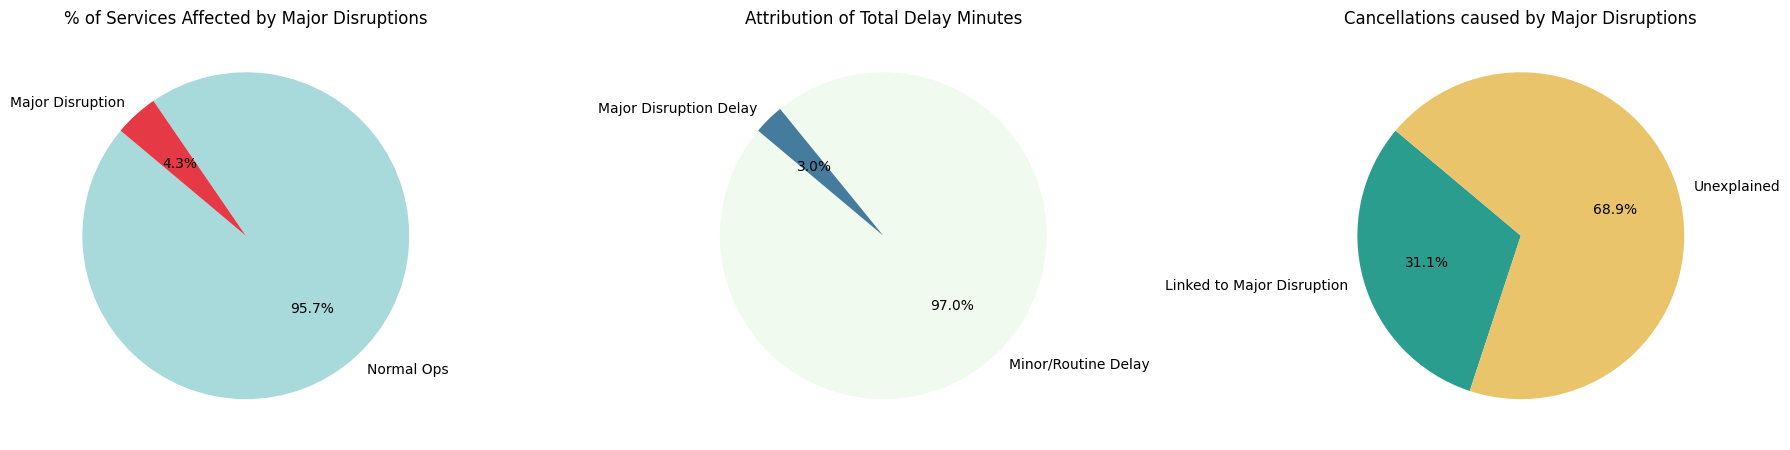

In [36]:
# --- Cell: Disruption Impact Analysis ---

print("1. Preparing spatial-temporal join helper...")

# A. Flatten the disruptions (Unnest the station list) so we can join on Station Code
# We filter out disruptions with zero duration or invalid times to keep joins fast.
con.execute("""
    CREATE OR REPLACE TEMP TABLE flat_disruptions AS
    SELECT 
        rdt_id,
        cause_nl,
        UNNEST(station_array) as station_code,
        start_time,
        end_time
    FROM disruptions
    WHERE duration_minutes > 0 
      AND start_time < end_time
""")

# B. Perform the "Big Join" (Range Join)
# This flags every service as 'Linked to Disruption' or 'Not Linked'
# Note: We use LEFT JOIN to keep all services, even those without disruptions.
print("2. Calculating Impact Metrics (this may take a moment)...")

impact_query = """
    WITH joined_data AS (
        SELECT 
            s.service_id,
            s.is_cancelled,
            s.arrival_delay_min,
            -- Check if this service falls into ANY disruption window at this station
            MAX(CASE WHEN d.rdt_id IS NOT NULL THEN 1 ELSE 0 END) as has_major_disruption
        FROM services s
        LEFT JOIN flat_disruptions d
          ON s.station_code = d.station_code
          AND s.arrival_time BETWEEN d.start_time AND d.end_time
        WHERE s.arrival_time IS NOT NULL -- Exclude arrival no planned
        GROUP BY 1, 2, 3
    )
    SELECT 
        -- Metric 1: Service Impact
        COUNT(*) as total_services,
        SUM(has_major_disruption) as disrupted_services,
        100.0 * SUM(has_major_disruption) / COUNT(*) as pct_services_disrupted,
        
        -- Metric 2: Ghost Cancellations (Cancelled but no disruption record found?)
        SUM(CASE WHEN is_cancelled=true THEN 1 ELSE 0 END) as total_cancellations,
        SUM(CASE WHEN is_cancelled=true AND has_major_disruption=1 THEN 1 ELSE 0 END) as explained_cancellations,
        100.0 * SUM(CASE WHEN is_cancelled=true AND has_major_disruption=0 THEN 1 ELSE 0 END) / NULLIF(SUM(CASE WHEN is_cancelled=true THEN 1 ELSE 0 END),0) as pct_unexplained_cancellations,

        -- Metric 3: Delay Attribution
        SUM(arrival_delay_min) as total_delay_minutes,
        SUM(CASE WHEN has_major_disruption=1 THEN arrival_delay_min ELSE 0 END) as disruption_caused_delay,
        100.0 * SUM(CASE WHEN has_major_disruption=1 THEN arrival_delay_min ELSE 0 END) / NULLIF(SUM(arrival_delay_min), 0) as pct_delay_from_major
    FROM joined_data
"""

df_impact = con.execute(impact_query).df()

# --- Reporting ---
print("\n=== 📊 Disruption Impact Report ===")
metrics = df_impact.iloc[0]

print(f"1. Total Services Analyzed:       {int(metrics['total_services']):,}")
print(f"2. Services with Major Disruption: {metrics['pct_services_disrupted']:.2f}%")
print(f"3. Delay Caused by Major Events:   {metrics['pct_delay_from_major']:.2f}% of all delay minutes")
print(f"   (Remaining {100-metrics['pct_delay_from_major']:.2f}% is likely 'minor' operations delay)")
print("-" * 40)
print(f"4. Total Cancellations:           {int(metrics['total_cancellations']):,}")
print(f"5. 'Ghost' Cancellations:         {metrics['pct_unexplained_cancellations']:.2f}%")
print("   (Services cancelled without a matching record in the Disruptions table)")

# --- Visualization ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot 1: Services Affected
axes[0].pie(
    [metrics['total_services'] - metrics['disrupted_services'], metrics['disrupted_services']],
    labels=['Normal Ops', 'Major Disruption'],
    autopct='%1.1f%%',
    colors=['#a8dadc', '#e63946'],
    startangle=140
)
axes[0].set_title("% of Services Affected by Major Disruptions")

# Plot 2: Delay Attribution
axes[1].pie(
    [metrics['total_delay_minutes'] - metrics['disruption_caused_delay'], metrics['disruption_caused_delay']],
    labels=['Minor/Routine Delay', 'Major Disruption Delay'],
    autopct='%1.1f%%',
    colors=['#f1faee', '#457b9d'],
    startangle=140
)
axes[1].set_title("Attribution of Total Delay Minutes")

# Plot 3: Cancellation Explanation
axes[2].pie(
    [metrics['explained_cancellations'], metrics['total_cancellations'] - metrics['explained_cancellations']],
    labels=['Linked to Major Disruption', 'Unexplained'],
    autopct='%1.1f%%',
    colors=['#2a9d8f', '#e9c46a'],
    startangle=140
)
axes[2].set_title("Cancellations caused by Major Disruptions")

plt.tight_layout()
plt.show()

Calculating count-based impact metrics...
Total Delayed Trains (>5 min): 1,754,370
 - Caused by Major Disruption: 3.3%
 - Routine/Minor Causes:       96.7%


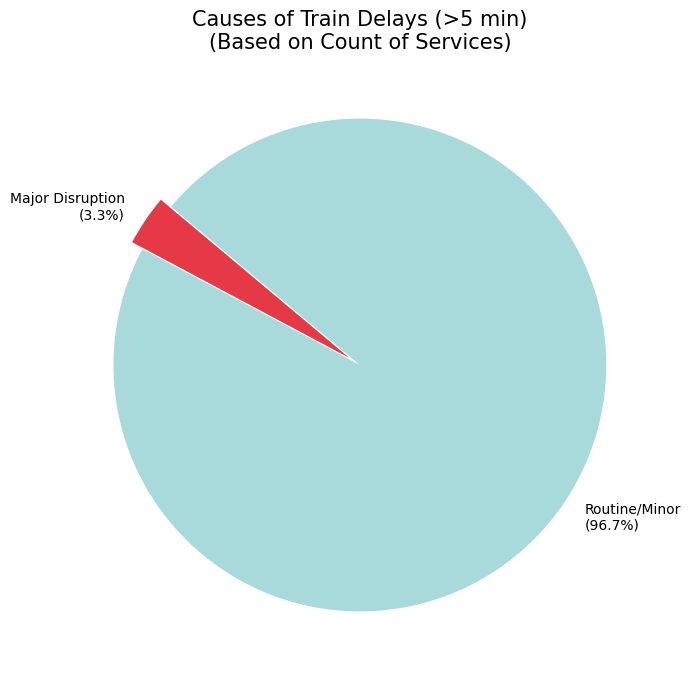

In [37]:
# --- Cell: Disruption Impact (Count of Delayed Trains) ---

print("Calculating count-based impact metrics...")

impact_count_query = """
    WITH joined_data AS (
        SELECT 
            s.service_id,
            s.arrival_delay_min,
            -- Flag if this specific train matches a disruption window
            MAX(CASE WHEN d.rdt_id IS NOT NULL THEN 1 ELSE 0 END) as linked_to_disruption
        FROM services s
        LEFT JOIN flat_disruptions d
          ON s.station_code = d.station_code
          AND s.arrival_time BETWEEN d.start_time AND d.end_time
        WHERE s.arrival_time IS NOT NULL
        GROUP BY 1, 2
    )
    SELECT 
        -- 1. Define the Population: All trains with Significant Delay (> 5 min)
        SUM(CASE WHEN arrival_delay_min >= 5 THEN 1 ELSE 0 END) as total_delayed_trains,
        
        -- 2. Count how many of those match a Major Disruption
        SUM(CASE WHEN arrival_delay_min >= 5 AND linked_to_disruption=1 THEN 1 ELSE 0 END) as explained_delays,
        
        -- 3. The remaining are "Unexplained" (Routine/Minor operational issues)
        SUM(CASE WHEN arrival_delay_min >= 5 AND linked_to_disruption=0 THEN 1 ELSE 0 END) as unexplained_delays
    FROM joined_data
"""

df_impact_count = con.execute(impact_count_query).df()
metrics = df_impact_count.iloc[0]

# --- Reporting ---
explained_pct = (metrics['explained_delays'] / metrics['total_delayed_trains']) * 100
unexplained_pct = (metrics['unexplained_delays'] / metrics['total_delayed_trains']) * 100

print(f"Total Delayed Trains (>5 min): {int(metrics['total_delayed_trains']):,}")
print(f" - Caused by Major Disruption: {explained_pct:.1f}%")
print(f" - Routine/Minor Causes:       {unexplained_pct:.1f}%")

# --- Plotting the New Pie Chart ---
plt.figure(figsize=(8, 8))
plt.pie(
    [metrics['explained_delays'], metrics['unexplained_delays']],
    labels=[f'Major Disruption\n({explained_pct:.1f}%)', f'Routine/Minor\n({unexplained_pct:.1f}%)'],
    colors=['#e63946', '#a8dadc'], # Red for disruption, Blue for routine
    autopct='', # We put the pct in the label manually above
    startangle=140,
    explode=(0.05, 0) # Highlight the disruption slice
)
plt.title("Causes of Train Delays (>5 min)\n(Based on Count of Services)", fontsize=15)
plt.show()

Calculating count-based impact metrics...
Total Delayed Trains (>0 min): 16,591,155
 - Caused by Major Disruption: 4.4%
 - Routine/Minor Causes:       95.6%


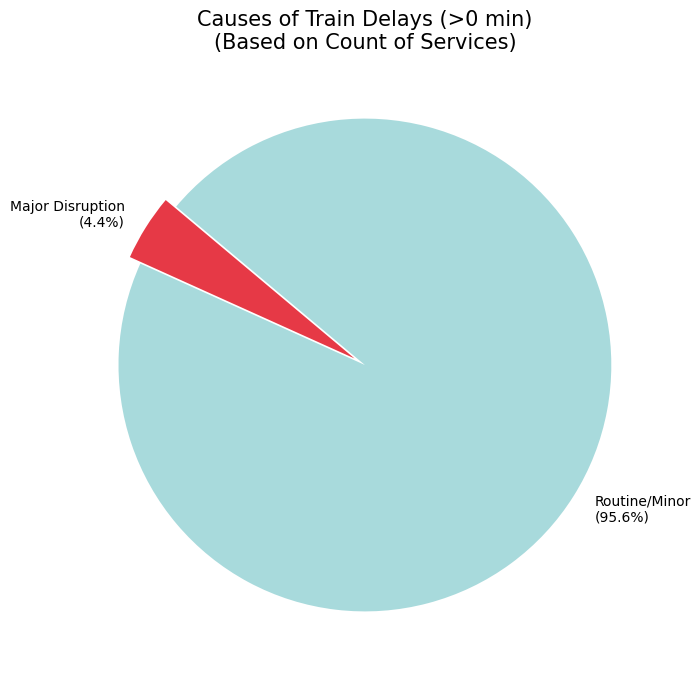

In [38]:
# --- Cell: Disruption Impact (Count of Delayed Trains) ---

print("Calculating count-based impact metrics...")

impact_count_query = """
    WITH joined_data AS (
        SELECT 
            s.service_id,
            s.arrival_delay_min,
            -- Flag if this specific train matches a disruption window
            MAX(CASE WHEN d.rdt_id IS NOT NULL THEN 1 ELSE 0 END) as linked_to_disruption
        FROM services s
        LEFT JOIN flat_disruptions d
          ON s.station_code = d.station_code
          AND s.arrival_time BETWEEN d.start_time AND d.end_time
        WHERE s.arrival_time IS NOT NULL
        GROUP BY 1, 2
    )
    SELECT 
        -- 1. Define the Population: All trains with Significant Delay (> 0 min)
        SUM(CASE WHEN arrival_delay_min >= 0 THEN 1 ELSE 0 END) as total_delayed_trains,
        
        -- 2. Count how many of those match a Major Disruption
        SUM(CASE WHEN arrival_delay_min >= 0 AND linked_to_disruption=1 THEN 1 ELSE 0 END) as explained_delays,
        
        -- 3. The remaining are "Unexplained" (Routine/Minor operational issues)
        SUM(CASE WHEN arrival_delay_min >= 0 AND linked_to_disruption=0 THEN 1 ELSE 0 END) as unexplained_delays
    FROM joined_data
"""

df_impact_count = con.execute(impact_count_query).df()
metrics = df_impact_count.iloc[0]

# --- Reporting ---
explained_pct = (metrics['explained_delays'] / metrics['total_delayed_trains']) * 100
unexplained_pct = (metrics['unexplained_delays'] / metrics['total_delayed_trains']) * 100

print(f"Total Delayed Trains (>0 min): {int(metrics['total_delayed_trains']):,}")
print(f" - Caused by Major Disruption: {explained_pct:.1f}%")
print(f" - Routine/Minor Causes:       {unexplained_pct:.1f}%")

# --- Plotting the New Pie Chart ---
plt.figure(figsize=(8, 8))
plt.pie(
    [metrics['explained_delays'], metrics['unexplained_delays']],
    labels=[f'Major Disruption\n({explained_pct:.1f}%)', f'Routine/Minor\n({unexplained_pct:.1f}%)'],
    colors=['#e63946', '#a8dadc'], # Red for disruption, Blue for routine
    autopct='', # We put the pct in the label manually above
    startangle=140,
    explode=(0.05, 0) # Highlight the disruption slice
)
plt.title("Causes of Train Delays (>0 min)\n(Based on Count of Services)", fontsize=15)
plt.show()

## Hourly Delay aggregation for (time series) prediction task (per station)

In [ ]:
# --- Cell: Create Hourly Time Series Aggregation ---

print("Aggregating services into hourly bins...")

hourly_delay_query = """
    SELECT 
        -- 1. Create Hourly Bins (Truncate time to the start of the hour)
        date_trunc('hour', arrival_time) as hour_bin,
        
        -- 2. Group by Station
        station_code,
        
        -- 3. Count Total Inbound Trains
        COUNT(*) as total_trains,
        
        -- 4. Count Delayed Trains (Delay > 0)
        SUM(CASE WHEN arrival_delay_min > 0 THEN 1 ELSE 0 END) as delayed_trains_count,
        
        -- 5. Total and Average Delay
        ROUND(SUM(arrival_delay_min), 1) as total_delay_minutes,
        ROUND(AVG(arrival_delay_min), 1) as avg_delay_minutes,
        
        -- Percentage of trains delayed 
        ROUND(100.0 * SUM(CASE WHEN arrival_delay_min > 0 THEN 1 ELSE 0 END) / COUNT(*), 1) as pct_delayed
        
    FROM services
    WHERE arrival_time IS NOT NULL 
      AND is_cancelled = false -- Usually you only analyze delays for trains that actually ran
    GROUP BY 1, 2
    ORDER BY 1, 2
"""

# Execute and store in a DataFrame
df_hourly = con.execute(hourly_delay_query).df()

# --- Preview ---
print(f"Created time series with {len(df_hourly):,} rows.")
display(df_hourly.head())

# --- Quick Sanity Check ---
# Check one major station (e.g., Utrecht Centraal 'Ut') to see if the curve looks right
print("\nSample for Utrecht Centraal (Ut):")
display(df_hourly[df_hourly['station_code'] == 'Ut'].head(5))

Aggregating services into hourly bins...
Created time series with 10,655,747 rows.


,hour_bin,station_code,total_trains,delayed_trains_count,total_delay_minutes,avg_delay_minutes,pct_delayed
0,2019-01-01 02:00:00+01:00,ASB,1,0.0,0.0,0.0,0.0
1,2019-01-01 02:00:00+01:00,ASD,1,1.0,1.0,1.0,100.0
2,2019-01-01 02:00:00+01:00,DT,1,0.0,0.0,0.0,0.0
3,2019-01-01 02:00:00+01:00,GV,1,1.0,1.0,1.0,100.0
4,2019-01-01 02:00:00+01:00,LEDN,1,0.0,0.0,0.0,0.0



Sample for Utrecht Centraal (Ut):


,hour_bin,station_code,total_trains,delayed_trains_count,total_delay_minutes,avg_delay_minutes,pct_delayed


In [85]:
# --- Cell: Show Full Database Schema ---

print("=== 📂 Database Tables & Views ===")
# 1. List all tables and views
tables_df = con.execute("SHOW TABLES").df()
display(tables_df)

print("\n=== 📝 Detailed Column Schema ===")
# 2. Get details (Column Name, Type) for every table
# We filter out internal system tables (pg_catalog, etc.) for clarity
schema_query = """
    SELECT 
        table_name,
        column_name,
        data_type,
        is_nullable
    FROM information_schema.columns
    WHERE table_schema = 'main'
    ORDER BY table_name, ordinal_position
"""

schema_df = con.execute(schema_query).df()

# Display clearly (grouped by table visually)
# We can just show the dataframe, or loop to make it readable
for table_name in schema_df['table_name'].unique():
    print(f"\nTable: {table_name}")
    subset = schema_df[schema_df['table_name'] == table_name]
    print(subset[['column_name', 'data_type']].to_string(index=False))

=== 📂 Database Tables & Views ===


,name
0,disruptions
1,holidays
2,raw_disruptions
3,raw_holidays
4,raw_services
5,raw_station_distances
6,raw_weather
7,services
8,stations



=== 📝 Detailed Column Schema ===

Table: disruptions
         column_name data_type
              rdt_id    BIGINT
            ns_lines   VARCHAR
           rdt_lines   VARCHAR
        rdt_lines_id   VARCHAR
   rdt_station_names   VARCHAR
   rdt_station_codes   VARCHAR
            cause_nl   VARCHAR
            cause_en   VARCHAR
statistical_cause_nl   VARCHAR
statistical_cause_en   VARCHAR
         cause_group   VARCHAR
          start_time TIMESTAMP
            end_time TIMESTAMP
    duration_minutes    BIGINT
            filename   VARCHAR
       station_array VARCHAR[]

Table: holidays
 column_name    data_type
        date TIMESTAMP_NS
holiday_name      VARCHAR
        year      INTEGER
 day_of_week      VARCHAR

Table: raw_disruptions
         column_name data_type
              rdt_id    BIGINT
            ns_lines   VARCHAR
           rdt_lines   VARCHAR
        rdt_lines_id   VARCHAR
   rdt_station_names   VARCHAR
   rdt_station_codes   VARCHAR
            cause_nl   VARCHAR


## Weather Dataset


### Weather features per time horizon

Analyzing temperature_2m...
Analyzing rain...
Analyzing snowfall...
Analyzing snow_depth...
Analyzing wind_speed_10m...
Analyzing wind_gusts_10m...
Analyzing soil_temperature_0_to_7cm...


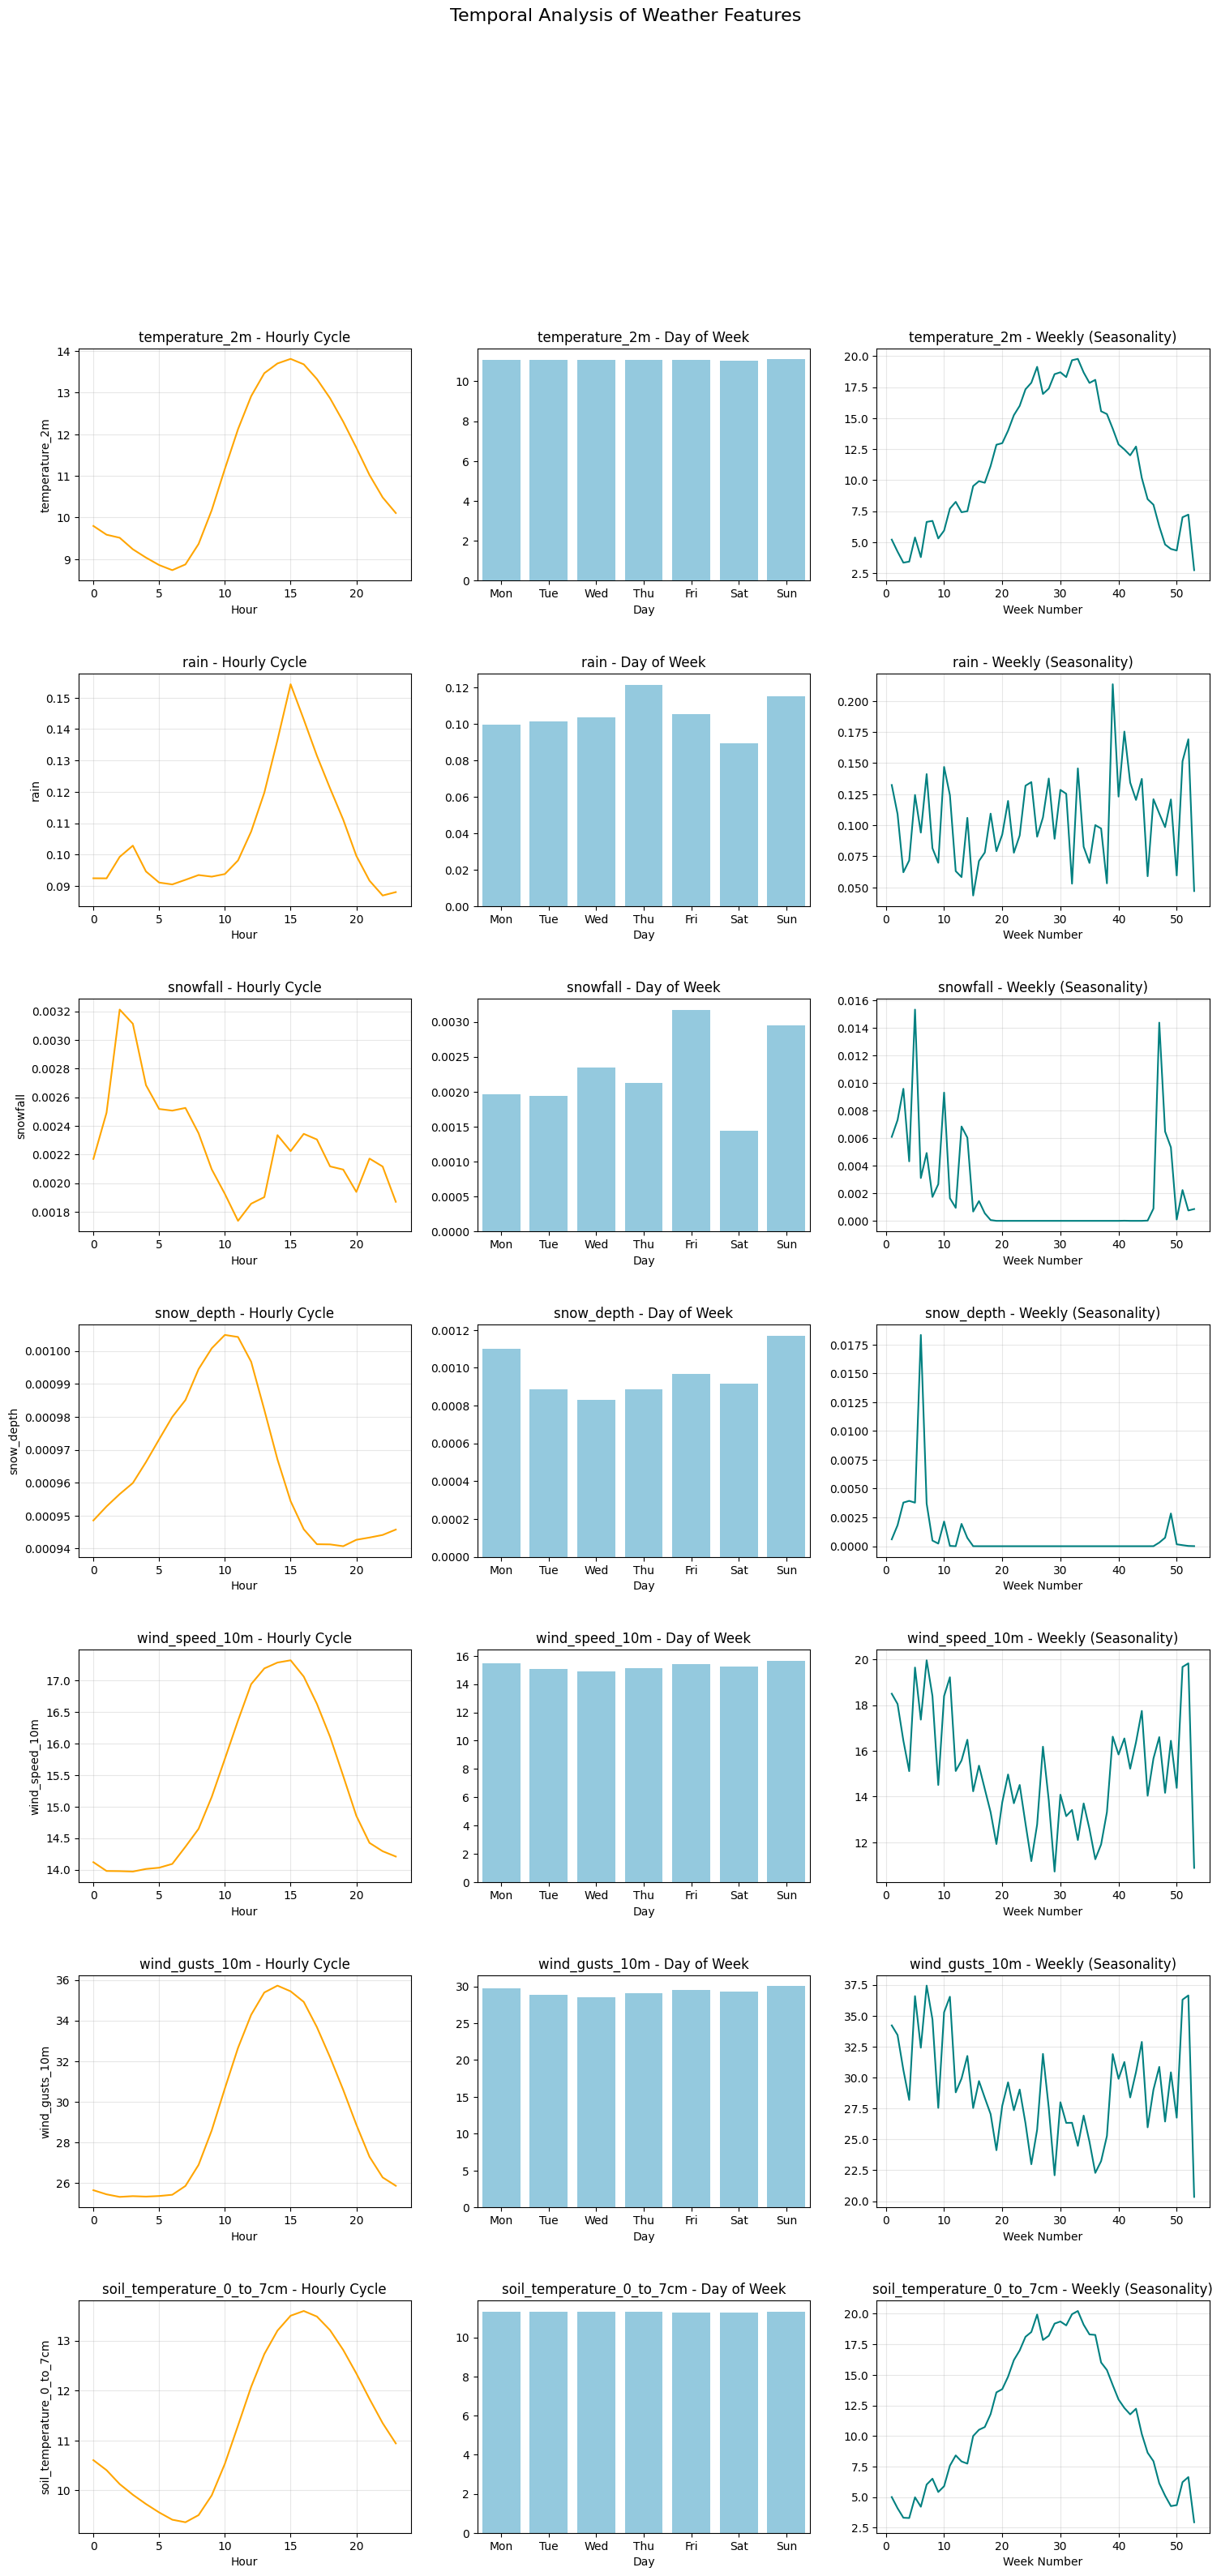

In [39]:
weather_features = [
    "temperature_2m", "rain", "snowfall", "snow_depth",
    "wind_speed_10m", "wind_gusts_10m", "soil_temperature_0_to_7cm"
]

# Set up the plot: One row per feature, 3 columns (Hourly, Daily, Weekly)
fig, axes = plt.subplots(len(weather_features), 3, figsize=(18, 5 * len(weather_features)))
plt.subplots_adjust(hspace=0.4, wspace=0.2)

for i, feature in enumerate(weather_features):
    print(f"Analyzing {feature}...")
    
    # 1. Hourly Trend
    hourly_query = f"""
        SELECT 
            HOUR(time) as hour_of_day,
            AVG({feature}) as mean_val
        FROM raw_weather
        GROUP BY 1
        ORDER BY 1
    """
    df_hourly = con.execute(hourly_query).df()
    
    # 2. Daily Trend (Day of Week) - mostly to check for data bias
    daily_query = f"""
        SELECT 
            ISODOW(time) as day_idx,  
            CASE ISODOW(time)         
                WHEN 1 THEN 'Mon' WHEN 2 THEN 'Tue' WHEN 3 THEN 'Wed'
                WHEN 4 THEN 'Thu' WHEN 5 THEN 'Fri' WHEN 6 THEN 'Sat' 
                WHEN 7 THEN 'Sun'     
            END as day_name,
            AVG({feature}) as mean_val
        FROM raw_weather
        GROUP BY 1, 2
        ORDER BY 1
    """
    df_daily = con.execute(daily_query).df()
    
    # 3. Weekly Trend (Seasonality)
    weekly_query = f"""
        SELECT 
            WEEK(time) as week_number,
            AVG({feature}) as mean_val
        FROM raw_weather
        GROUP BY 1
        ORDER BY 1
    """
    df_weekly = con.execute(weekly_query).df()
    
    # --- Plotting ---
    
    # Hourly Plot
    sns.lineplot(data=df_hourly, x='hour_of_day', y='mean_val', ax=axes[i, 0], color='orange')
    axes[i, 0].set_title(f'{feature} - Hourly Cycle')
    axes[i, 0].set_ylabel(feature)
    axes[i, 0].set_xlabel("Hour")
    axes[i, 0].grid(True, alpha=0.3)
    
    # Daily Plot
    sns.barplot(data=df_daily, x='day_name', y='mean_val', ax=axes[i, 1], color='skyblue')
    axes[i, 1].set_title(f'{feature} - Day of Week')
    axes[i, 1].set_ylabel("") # Save space
    axes[i, 1].set_xlabel("Day")
    
    # Weekly Plot
    sns.lineplot(data=df_weekly, x='week_number', y='mean_val', ax=axes[i, 2], color='teal')
    axes[i, 2].set_title(f'{feature} - Weekly (Seasonality)')
    axes[i, 2].set_ylabel("") # Save space
    axes[i, 2].set_xlabel("Week Number")
    axes[i, 2].grid(True, alpha=0.3)

plt.suptitle("Temporal Analysis of Weather Features", fontsize=16, y=1.00)
plt.show()

## Holidays Dataset

Mean delay higher in normal days normal days but probably due to larger sample size

-> outliers remove or include? (WHERE clause)

Analyzing Holiday Impact...
Impact Summary:
     day_type  mean_delay  total_trains
0  Normal Day    0.707656      81512490
1     Holiday    0.487660       1979868


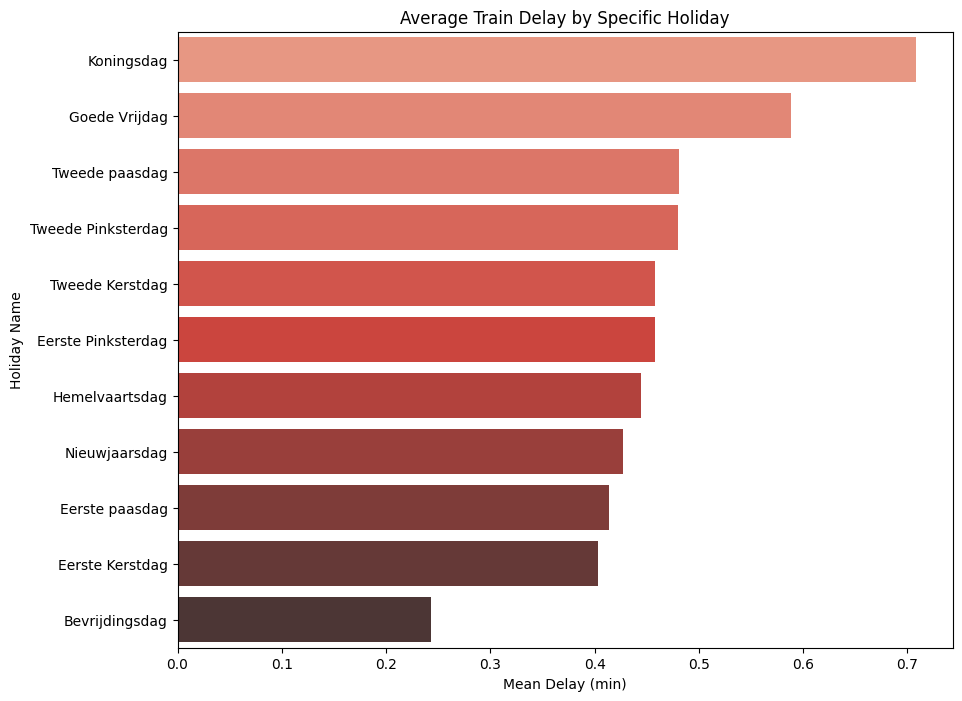

In [41]:
# --- Cell: Holiday Impact Analysis ---

# # 1. Register Holidays Table
# holiday_path = root_folder / "holidays/dutch_holidays_2019_2025.parquet"
# con.execute(f"CREATE OR REPLACE TABLE holidays AS SELECT * FROM read_parquet('{holiday_path}')")

# 2. Compare Delays: Holiday vs Normal Day
print("Analyzing Holiday Impact...")
holiday_query = """
    WITH data_labeled AS (
        SELECT 
            s.arrival_delay_min,
            CASE 
                -- Cast timestamp to date for the join
                WHEN h.date IS NOT NULL THEN 'Holiday' 
                ELSE 'Normal Day'
            END as day_type
        FROM services s
        -- JOIN CONDITION: Match Service Date to Holiday Date
        LEFT JOIN raw_holidays h ON s.service_date = CAST(h.date AS DATE)
        -- WHERE s.arrival_delay_min BETWEEN 0 AND 120 
    )
    SELECT 
        day_type,
        AVG(arrival_delay_min) as mean_delay,
        COUNT(*) as total_trains
    FROM data_labeled
    GROUP BY 1
"""
df_impact = con.execute(holiday_query).df()
print("Impact Summary:")
print(df_impact)

# 3. Specific Holiday Ranking (Which holiday is the worst?)
ranking_query = """
    SELECT 
        h.holiday_name,
        AVG(s.arrival_delay_min) as mean_delay,
        COUNT(*) as train_count
    FROM services s
    JOIN holidays h ON s.service_date = CAST(h.date AS DATE)
    GROUP BY 1
    HAVING train_count > 500 -- Ensure statistical significance
    ORDER BY 2 DESC
"""
df_ranking = con.execute(ranking_query).df()

# Plotting
plt.figure(figsize=(10, 8))
sns.barplot(data=df_ranking, x='mean_delay', y='holiday_name', palette='Reds_d', hue='holiday_name', legend=False)
plt.title("Average Train Delay by Specific Holiday")
plt.xlabel("Mean Delay (min)")
plt.ylabel("Holiday Name")
plt.show()

In [ ]:
# --- Optimized Network Query ---
# This ensures we only pull a tiny DataFrame (Sources, Targets, Counts) into Python
# rather than raw rows.
# 1. Get Edges (Connections)
print("1. Extracting Network Edges...")
edges_query = """
    WITH ordered_stops AS (
        SELECT 
            service_id,
            station_code as source,
            departure_time,
            LEAD(station_code) OVER (PARTITION BY service_id ORDER BY departure_time) as target
        FROM services
        WHERE is_cancelled = false
    )
    SELECT source, target, COUNT(*) as frequency
    FROM ordered_stops
    WHERE target IS NOT NULL
    GROUP BY 1, 2
    HAVING frequency > 50
"""
edges_df = con.execute(edges_query).df()

1. Extracting Network Edges...


In [ ]:
# 2. Get the Nodes (Station Coordinates) and station type
print("2. Extracting Station Metadata...")
nodes_query = """
    SELECT 
        code, 
        name_short as name, 
        geo_lat, 
        geo_lng,
        type as station_type 
    FROM stations
    WHERE country = 'NL'
"""
nodes_df = con.execute(nodes_query).df()

2. Extracting Station Metadata...


In [50]:
# Define Color Mapping based on hierarchy
# Red/Orange = Major Hubs, Greens = Fast trains, Blues = Local, Grey = Event only
type_colors = {
    'megastation': '#d62728',               # Red
    'knooppuntIntercitystation': '#ff7f0e', # Orange
    'intercitystation': '#ffbb78',          # Light Orange
    'knooppuntSneltreinstation': '#2ca02c', # Green
    'sneltreinstation': '#98df8a',          # Light Green
    'knooppuntStoptreinstation': '#17becf', # Cyan
    'stoptreinstation': '#1f77b4',          # Blue
    'facultatiefStation': '#7f7f7f'         # Grey
}

Constructing Networks...


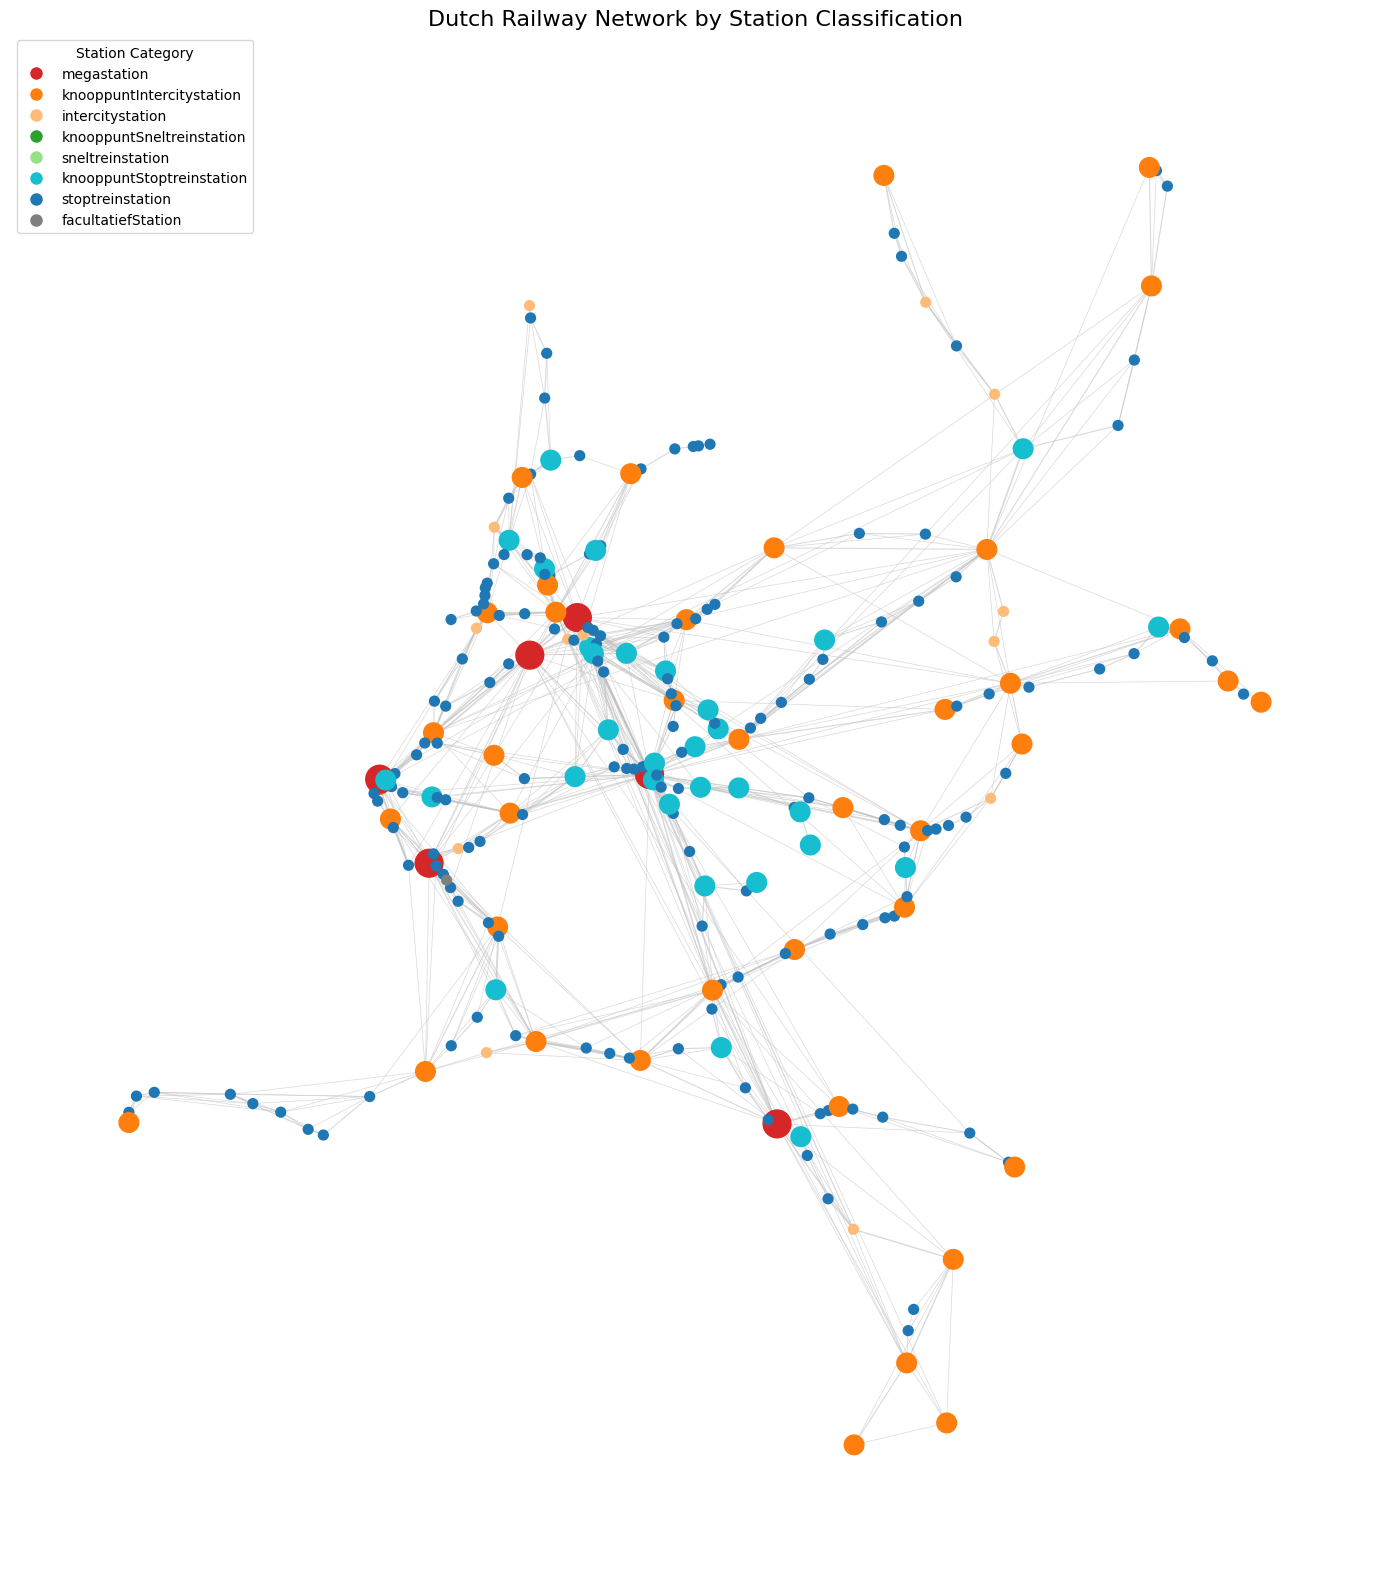


=== 🏭 Station Composition Summary ===
station_type
stoptreinstation             159
knooppuntIntercitystation     40
knooppuntStoptreinstation     31
intercitystation              13
megastation                    6
facultatiefStation             1
Name: count, dtype: int64


In [54]:
# Add Nodes with attributes
node_positions = {}
node_colors_list = []
node_sizes_list = []

def build_network(connection, train_type_filter=None):
    """
    Builds a NetworkX graph from the services table.
    If train_type_filter is provided (e.g., 'Intercity'), filters for that type.
    """
    # Base SQL
    where_clause = "WHERE is_cancelled = false"
    if train_type_filter:
        where_clause += f" AND train_type = '{train_type_filter}'"
    
    query = f"""
        WITH ordered_stops AS (
            SELECT 
                service_id,
                station_code as source,
                departure_time,
                LEAD(station_code) OVER (PARTITION BY service_id ORDER BY departure_time) as target
            FROM services
            {where_clause}
        )
        SELECT 
            source, target, COUNT(*) as frequency
        FROM ordered_stops
        WHERE target IS NOT NULL
        GROUP BY 1, 2
        HAVING frequency > 10 -- Lower threshold to catch smaller lines
    """
    edges = connection.execute(query).df()
    
    # Construct Graph
    G = nx.Graph() # Undirected graph (tracks go both ways)
    for _, row in edges.iterrows():
        G.add_edge(row['source'], row['target'], weight=row['frequency'])
    
    return G

# 2. Build the three networks
print("Constructing Networks...")
G_all = build_network(con)

# 3. Build the Graph
G = nx.Graph()
# Helper to process nodes in correct order for plotting
# We build a dict first to look them up fast
node_meta = nodes_df.set_index('code').to_dict('index')

for code in G_all.nodes(): # Use the G_all we built earlier to ensure we match the network
    if code in node_meta:
        meta = node_meta[code]
        G.add_node(code, **meta)
        node_positions[code] = (meta['geo_lng'], meta['geo_lat'])
        
        # Assign Color
        st_type = meta.get('station_type', 'stoptreinstation') # Default to stop if missing
        node_colors_list.append(type_colors.get(st_type, '#c7c7c7'))
        
        # Assign Size (Megastations larger)
        if 'megastation' in st_type: size = 300
        elif 'knooppunt' in st_type: size = 150
        elif 'intercity' in st_type: size = 100
        else: size = 40
        node_sizes_list.append(size)

# Filter edges to only those with valid nodes
valid_edges = []
weights = []
for u, v, data in G_all.edges(data=True):
    if u in node_positions and v in node_positions:
        valid_edges.append((u, v))
        weights.append(data['weight'])

# 4. Plotting
plt.figure(figsize=(14, 16))
ax = plt.gca()

# Draw Edges
# Normalize weights for thickness
if weights:
    max_w = max(weights)
    widths = [0.5 + (w / max_w * 3) for w in weights]
else:
    widths = 0.5

nx.draw_networkx_edges(G_all, pos=node_positions, edgelist=valid_edges, 
                       width=widths, edge_color='silver', alpha=0.6, ax=ax)

# Draw Nodes manually to ensure alignment of colors/sizes
# We need to iterate again to ensure list order matches G.nodes() order exactly
final_nodes = [n for n in G_all.nodes() if n in node_positions]
final_colors = [type_colors.get(node_meta[n].get('station_type'), 'grey') for n in final_nodes]
final_sizes = []
for n in final_nodes:
    t = node_meta[n].get('station_type', '')
    if 'megastation' in t: s = 400
    elif 'knooppunt' in t: s = 200
    else: s = 50
    final_sizes.append(s)

nx.draw_networkx_nodes(G_all, pos=node_positions, nodelist=final_nodes, 
                       node_color=final_colors, node_size=final_sizes, ax=ax)

# Legend (Manual)
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor=c, label=l, markersize=10) 
                   for l, c in type_colors.items()]
ax.legend(handles=legend_elements, title="Station Category", loc='upper left')

plt.title("Dutch Railway Network by Station Classification", fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()

# 5. Summary Table of Station Types
print("\n=== 🏭 Station Composition Summary ===")
type_counts = nodes_df[nodes_df['code'].isin(final_nodes)]['station_type'].value_counts()
print(type_counts)